###Imports

In [1]:
#Lib imports

!pip install kagglehub tqdm matplotlib
!pip install pandas
!pip install seaborn
!pip install scikit-learn
!pip install numpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import random
import kagglehub
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

#Downloading Data Set

In [2]:
def download_NASAset():

  path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
  print(f"Downloaded dataset to: {path}")
  DATA_DIR = path

  # List contents of the downloaded directory to find the actual data path
  print(f"Contents of {DATA_DIR}:")
  for root, dirs, files in os.walk(DATA_DIR):
      level = root.replace(DATA_DIR, '').count(os.sep)
      indent = ' ' * 4 * (level)
      print(f'{indent}{os.path.basename(root)}/')
      subindent = ' ' * 4 * (level + 1)
      for f in files:
          print(f'{subindent}{f}')

  train_df = pd.read_csv(
    os.path.join(DATA_DIR, "CMaps", "train_FD001.txt"),
    sep=r"\s+",
    header=None
)

  test_df = pd.read_csv(
    os.path.join(DATA_DIR, "CMaps", "test_FD001.txt"),
    sep=r"\s+",
    header=None
)

  rul_test = pd.read_csv(
    os.path.join(DATA_DIR, "CMaps", "RUL_FD001.txt"),
    header=None,
    names=["RUL_end"]
)

  print("Dataframes loaded successfully.")
  return train_df, test_df, rul_test

In [3]:
train_df, test_df, rul_test = download_NASAset()
print(f"Train DataFrame Shape: {train_df.shape}")
print(f"Test DataFrame Shape: {test_df.shape}")
print(f"RUL DataFrame Shape: {rul_test.shape}")

Downloaded dataset to: /home/hunterantal/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1
Contents of /home/hunterantal/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1:
1/
    CMaps/
        train_FD004.txt
        RUL_FD003.txt
        train_FD003.txt
        train_FD001.txt
        RUL_FD004.txt
        test_FD003.txt
        train_FD002.txt
        test_FD004.txt
        readme.txt
        RUL_FD002.txt
        RUL_FD001.txt
        Damage Propagation Modeling.pdf
        test_FD002.txt
        x.txt
        test_FD001.txt
Dataframes loaded successfully.
Train DataFrame Shape: (20631, 26)
Test DataFrame Shape: (13096, 26)
RUL DataFrame Shape: (100, 1)


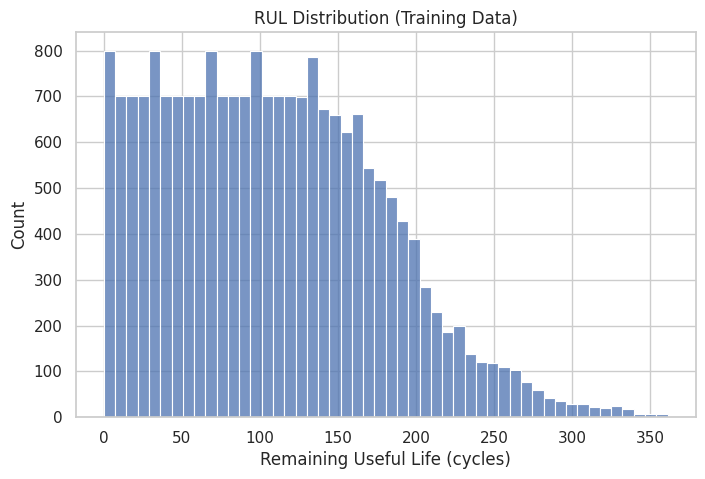

In [4]:
#Visualizing Raw Data
# Assign column names as the dataset was loaded without headers
column_names = [
    "engine_id",
    "cycle",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

train_df.columns = column_names
test_df.columns = column_names

# Create RUL labels for training data (for visualization only)
train_vis = train_df.copy()

max_cycles = train_vis.groupby("engine_id")["cycle"].max()
train_vis["RUL"] = train_vis.apply(
    lambda row: max_cycles[row["engine_id"]] - row["cycle"],
    axis=1
)

# Plot RUL distribution
plt.figure()
sns.histplot(train_vis["RUL"], bins=50)
plt.title("RUL Distribution (Training Data)")
plt.xlabel("Remaining Useful Life (cycles)")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_1289842/3539466974.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


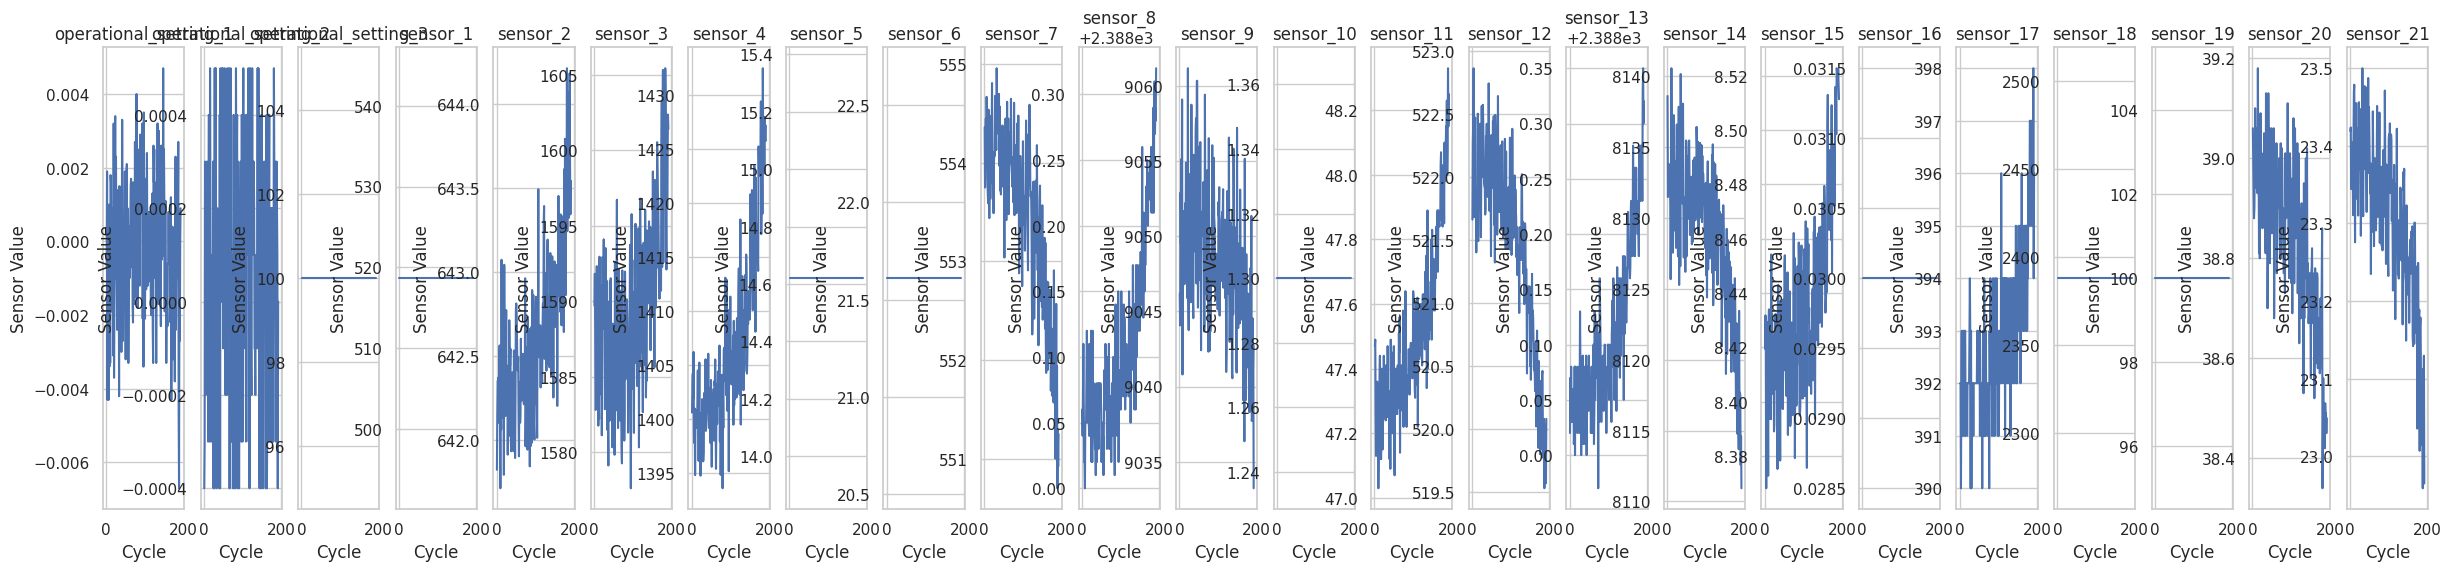

In [5]:
# Number of engines to plot (you can adjust this)
engines_to_plot = train_df["engine_id"].unique()[:1]  # First 5 engines for example

# Set up the figure and subplots
fig, axes = plt.subplots(nrows=len(engines_to_plot), ncols=24, figsize=(30, len(engines_to_plot) * 6))

# Plot all sensors and operational settings for each engine
sensors_to_plot = ["operational_setting_1", "operational_setting_2", "operational_setting_3"] + \
                  [f"sensor_{i}" for i in range(1, 22)]

for idx, engine_id in enumerate(engines_to_plot):
    engine_df = train_df[train_df["engine_id"] == engine_id]

    # Plot each sensor and operational setting for this engine
    for i, sensor in enumerate(sensors_to_plot):
        ax = axes[idx, i] if len(engines_to_plot) > 1 else axes[i]  # Handle single engine case
        ax.plot(engine_df["cycle"], engine_df[sensor])
        ax.set_title(f"{sensor}")
        ax.set_xlabel("Cycle")
        ax.set_ylabel("Sensor Value")

plt.tight_layout()
plt.show()


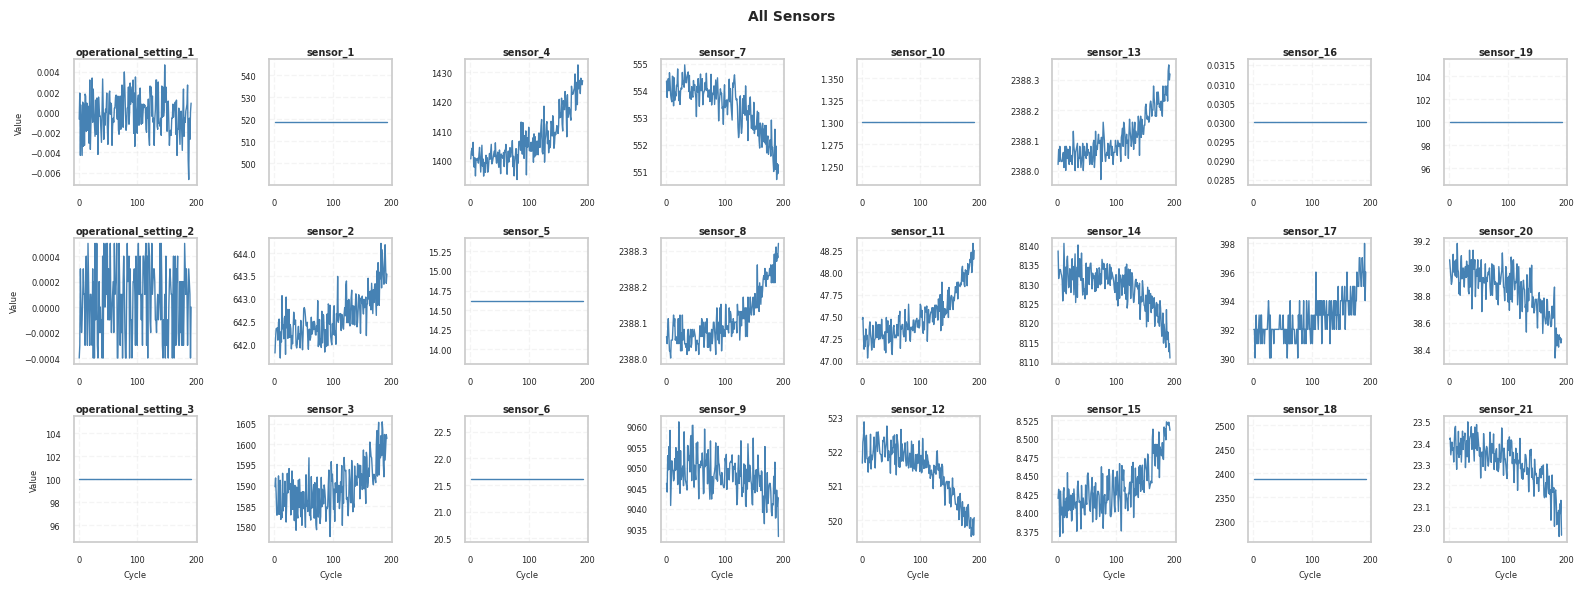

In [6]:
# All sensors raw data
engines_to_plot = train_df["engine_id"].unique()[:1]
engine_id = engines_to_plot[0]
engine_df = train_df[train_df["engine_id"] == engine_id]

sensors_to_plot = ["operational_setting_1", "operational_setting_2", "operational_setting_3"] + \
                  [f"sensor_{i}" for i in range(1, 22)]

n_cols = 8
n_rows = 3

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 6))

for i, sensor in enumerate(sensors_to_plot):
    col = i // n_rows
    row = i % n_rows

    ax = axes[row, col]
    ax.plot(engine_df["cycle"], engine_df[sensor], linewidth=1, color='steelblue')
    ax.set_title(sensor, fontsize=7, fontweight='bold', pad=3)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.tick_params(axis='both', labelsize=6)

    # FIX: Disable scientific notation offset
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)

    if row == n_rows - 1:
        ax.set_xlabel("Cycle", fontsize=6)
    if col == 0:
        ax.set_ylabel("Value", fontsize=6)

# Hide unused subplots
for i in range(len(sensors_to_plot), n_rows * n_cols):
    col = i // n_rows
    row = i % n_rows
    axes[row, col].axis('off')

plt.suptitle(f'All Sensors', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

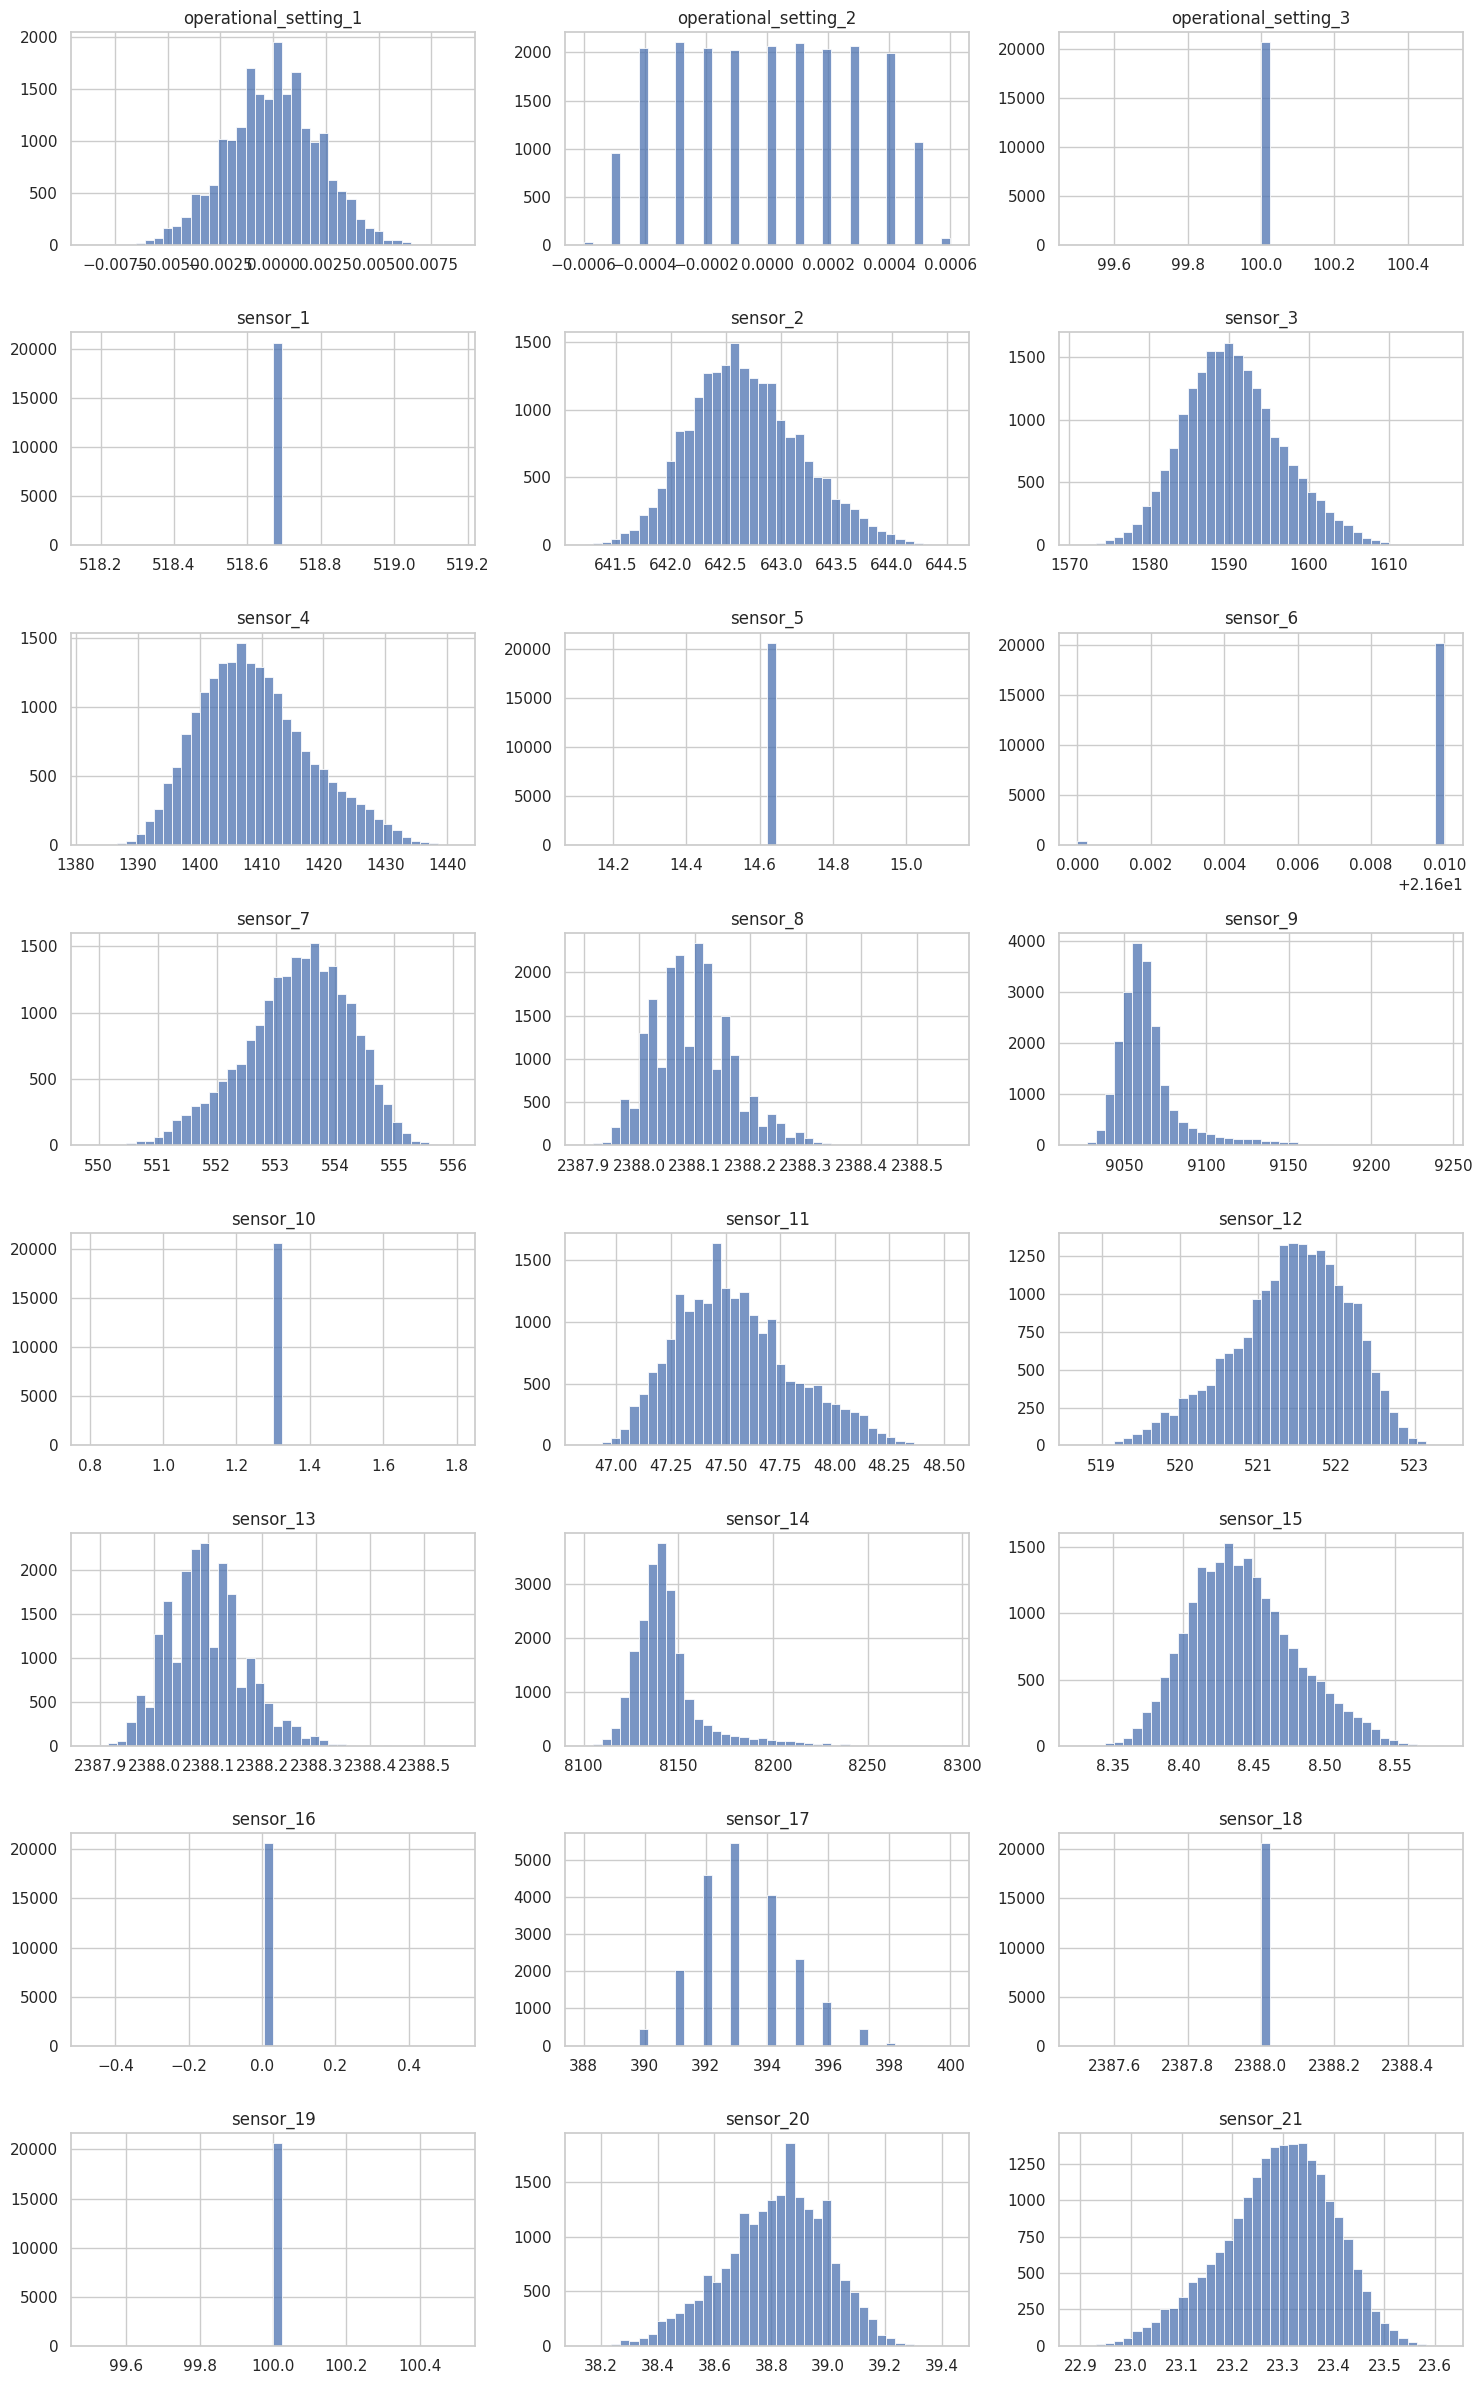

In [7]:
sensors_to_check = ["operational_setting_1",
    "operational_setting_2",
    "operational_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"]

# Calculate number of rows needed for the subplots
n_cols = 3
n_rows = (len(sensors_to_check) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 3)) # Adjust figure size dynamically
for i, sensor in enumerate(sensors_to_check, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(train_df[sensor], bins=40)
    plt.title(sensor)
    plt.xlabel('') # Remove x-axis label to prevent overlap
    plt.ylabel('') # Remove y-axis label to prevent overlap

plt.tight_layout()
plt.show()

In [8]:
# How many unique engines?
n_engines = train_df['engine_id'].nunique()
print(f"Number of unique engines: {n_engines}")

# How many total data points?
n_total_points = len(train_df)
print(f"Total data points: {n_total_points}")

# Average cycles per engine
avg_cycles = train_df.groupby('engine_id')['cycle'].max().mean()
print(f"Average lifespan: {avg_cycles:.1f} cycles")

# RUL value counts
print("\nRUL = 0 count:", (train_vis['RUL'] == 0).sum())
print("RUL = 125 count:", (train_vis['RUL'] == 125).sum())
print("RUL = 200 count:", (train_vis['RUL'] == 200).sum())
print("RUL = 275 count:", (train_vis['RUL'] == 275).sum())
print("RUL = 350 count:", (train_vis['RUL'] == 350).sum())

Number of unique engines: 100
Total data points: 20631
Average lifespan: 206.3 cycles

RUL = 0 count: 100
RUL = 125 count: 100
RUL = 200 count: 46
RUL = 275 count: 10
RUL = 350 count: 1


In [9]:
display(train_vis.columns)

Index(['engine_id', 'cycle', 'operational_setting_1', 'operational_setting_2',
       'operational_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
       'sensor_21', 'RUL'],
      dtype='str')

In [10]:
num_cycles = train_df["cycle"].nunique()
print(f"Number of unique cycles: {num_cycles}")


Number of unique cycles: 362


In [11]:
import pandas as pd

# Get the list of unique cycles
unique_cycles = train_df["cycle"].unique()

# Define columns to display: engine_id, cycle, and sensor readings
columns_to_display = ["engine_id", "cycle"] + ["operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"] + [f"sensor_{i}" for i in range(1, 22)]

# Loop over each cycle and create a table
for cycle_num in unique_cycles:
    cycle_df = train_df[train_df["cycle"] == cycle_num]  # Filter data for the current cycle
    cycle_table = cycle_df[columns_to_display]  # Select relevant columns
    # Display the table for this cycle using the standard display function
    print(f"\nEngine Sensor Data at Cycle {cycle_num}:")
    display(cycle_table)


Engine Sensor Data at Cycle 1:


,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
192,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,522.33,2388.06,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585
479,3,1,0.0008,0.0005,100.0,518.67,642.04,1584.20,1398.13,14.62,...,522.24,2388.00,8138.40,8.4207,0.03,391,2388,100.0,38.96,23.3205
658,4,1,0.0025,0.0005,100.0,518.67,642.60,1585.40,1402.85,14.62,...,521.94,2388.07,8131.50,8.4200,0.03,393,2388,100.0,39.04,23.3814
847,5,1,0.0031,0.0002,100.0,518.67,641.77,1583.59,1395.26,14.62,...,522.34,2388.00,8152.22,8.4102,0.03,393,2388,100.0,38.98,23.4468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19552,96,1,-0.0014,-0.0004,100.0,518.67,642.03,1579.12,1404.22,14.62,...,522.26,2388.06,8133.36,8.4293,0.03,392,2388,100.0,38.82,23.4178
19888,97,1,-0.0038,0.0003,100.0,518.67,642.01,1581.83,1395.40,14.62,...,522.34,2388.05,8130.81,8.4027,0.03,391,2388,100.0,38.94,23.3732
20090,98,1,0.0019,-0.0002,100.0,518.67,642.30,1580.93,1404.55,14.62,...,522.30,2387.97,8150.69,8.3792,0.03,392,2388,100.0,39.01,23.4547
20246,99,1,0.0011,0.0005,100.0,518.67,641.69,1586.17,1391.14,14.62,...,522.65,2388.06,8131.23,8.4038,0.03,391,2388,100.0,39.01,23.4007



Engine Sensor Data at Cycle 2:


,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
193,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,522.70,2387.98,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085
480,3,2,-0.0010,0.0000,100.0,518.67,642.66,1587.04,1398.62,14.62,...,522.03,2388.01,8137.38,8.3949,0.03,390,2388,100.0,39.07,23.4369
659,4,2,0.0002,-0.0004,100.0,518.67,642.45,1583.54,1410.36,14.62,...,521.70,2388.04,8129.53,8.3999,0.03,391,2388,100.0,39.02,23.4437
848,5,2,0.0002,0.0003,100.0,518.67,642.42,1589.69,1394.88,14.62,...,522.60,2387.99,8153.04,8.4053,0.03,392,2388,100.0,39.12,23.4075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19553,96,2,0.0004,-0.0002,100.0,518.67,641.99,1585.80,1396.96,14.62,...,522.31,2388.17,8136.21,8.4423,0.03,392,2388,100.0,39.01,23.3585
19889,97,2,-0.0018,-0.0001,100.0,518.67,641.99,1582.99,1402.05,14.62,...,522.06,2388.08,8131.43,8.4072,0.03,392,2388,100.0,39.14,23.3984
20091,98,2,0.0025,0.0000,100.0,518.67,642.13,1585.29,1394.47,14.62,...,521.80,2388.03,8147.03,8.4158,0.03,392,2388,100.0,38.91,23.3055
20247,99,2,0.0004,0.0001,100.0,518.67,641.93,1588.58,1402.26,14.62,...,521.61,2388.06,8132.70,8.4303,0.03,392,2388,100.0,39.05,23.4220



Engine Sensor Data at Cycle 3:


...

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
13990,69,360,0.0004,-0.0001,100.0,518.67,643.97,1597.75,1428.85,14.62,...,518.69,2388.26,8126.63,8.5059,0.03,396,2388,100.0,38.47,23.0422



Engine Sensor Data at Cycle 361:


,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
13991,69,361,0.0016,-0.0002,100.0,518.67,643.65,1603.5,1433.95,14.62,...,520.48,2388.32,8132.97,8.527,0.03,396,2388,100.0,38.52,23.1208



Engine Sensor Data at Cycle 362:


,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
13992,69,362,0.0007,-0.0,100.0,518.67,643.75,1598.16,1428.28,14.62,...,519.12,2388.33,8124.27,8.5126,0.03,397,2388,100.0,38.42,22.9782


#Additional EDA
Determining which features to remove

In [12]:
# Calculate variance for all features (excluding 'engine_id' and 'cycle')
feature_columns = [col for col in train_df.columns if col not in ['engine_id', 'cycle']]
variance = train_df[feature_columns].var()

# Display variance for each feature
print(variance)


operational_setting_1    4.784340e-06
operational_setting_2    8.588541e-08
operational_setting_3    0.000000e+00
sensor_1                 0.000000e+00
sensor_2                 2.500533e-01
sensor_3                 3.759099e+01
sensor_4                 8.101089e+01
sensor_5                 3.155597e-30
sensor_6                 1.929279e-06
sensor_7                 7.833883e-01
sensor_8                 5.038938e-03
sensor_9                 4.876536e+02
sensor_10                0.000000e+00
sensor_11                7.133568e-02
sensor_12                5.439850e-01
sensor_13                5.172330e-03
sensor_14                3.639005e+02
sensor_15                1.406628e-03
sensor_16                1.926023e-34
sensor_17                2.398667e+00
sensor_18                0.000000e+00
sensor_19                0.000000e+00
sensor_20                3.266927e-02
sensor_21                1.171825e-02
dtype: float64


In [13]:
# Calculate covariance between each sensor and RUL using train_vis
covariance = train_vis[feature_columns + ['RUL']].cov()

# Display covariance matrix
print(covariance)

                       operational_setting_1  operational_setting_2  \
operational_setting_1           4.784340e-06           7.474561e-09   
operational_setting_2           7.474561e-09           8.588541e-08   
operational_setting_3           0.000000e+00           0.000000e+00   
sensor_1                        0.000000e+00           0.000000e+00   
sensor_2                        9.876628e-06           1.064844e-06   
sensor_3                       -7.578547e-05           1.629315e-05   
sensor_4                        1.878934e-04           3.870308e-05   
sensor_5                       -2.330161e-35           4.720069e-35   
sensor_6                       -4.072360e-09           5.843159e-09   
sensor_7                       -1.827042e-05          -4.326030e-06   
sensor_8                       -6.625059e-08           2.763643e-07   
sensor_9                       -2.066758e-04          -3.510851e-05   
sensor_10                       0.000000e+00           0.000000e+00   
sensor

[25 rows x 25 columns]


In [14]:
# Calculate correlation between each sensor and RUL
correlation = train_vis[feature_columns + ['RUL']].corr()

# Display the correlation matrix
print(correlation['RUL'])  # Correlation with RUL only


operational_setting_1   -0.003198
operational_setting_2   -0.001948
operational_setting_3         NaN
sensor_1                      NaN
sensor_2                -0.606484
sensor_3                -0.584520
sensor_4                -0.678948
sensor_5                      NaN
sensor_6                -0.128348
sensor_7                 0.657223
sensor_8                -0.563968
sensor_9                -0.390102
sensor_10                     NaN
sensor_11               -0.696228
sensor_12                0.671983
sensor_13               -0.562569
sensor_14               -0.306769
sensor_15               -0.642667
sensor_16                     NaN
sensor_17               -0.606154
sensor_18                     NaN
sensor_19                     NaN
sensor_20                0.629428
sensor_21                0.635662
RUL                      1.000000
Name: RUL, dtype: float64



Features that do not meet the thresholds:
Low Variance: operational_setting_1 (Variance: 4.784340124242533e-06)
Low Variance: operational_setting_2 (Variance: 8.588540885522267e-08)
Low Variance: operational_setting_3 (Variance: 0.0)
Low Variance: sensor_1 (Variance: 0.0)
Low Variance: sensor_5 (Variance: 3.15559657501012e-30)
Low Variance: sensor_6 (Variance: 1.929279087728537e-06)
Low Variance: sensor_8 (Variance: 0.005038938213373842)
Low Variance: sensor_10 (Variance: 0.0)
Low Variance: sensor_13 (Variance: 0.005172330435259187)
Low Variance: sensor_15 (Variance: 0.0014066278717784488)
Low Variance: sensor_16 (Variance: 1.926023300177075e-34)
Low Variance: sensor_18 (Variance: 0.0)
Low Variance: sensor_19 (Variance: 0.0)
Low Covariance: operational_setting_1 (Covariance with RUL: -0.00048189342036734185)
Low Covariance: operational_setting_2 (Covariance with RUL: -3.931562311354976e-05)
Low Covariance: operational_setting_3 (Covariance with RUL: 0.0)
Low Covariance: sensor_1 (Cova

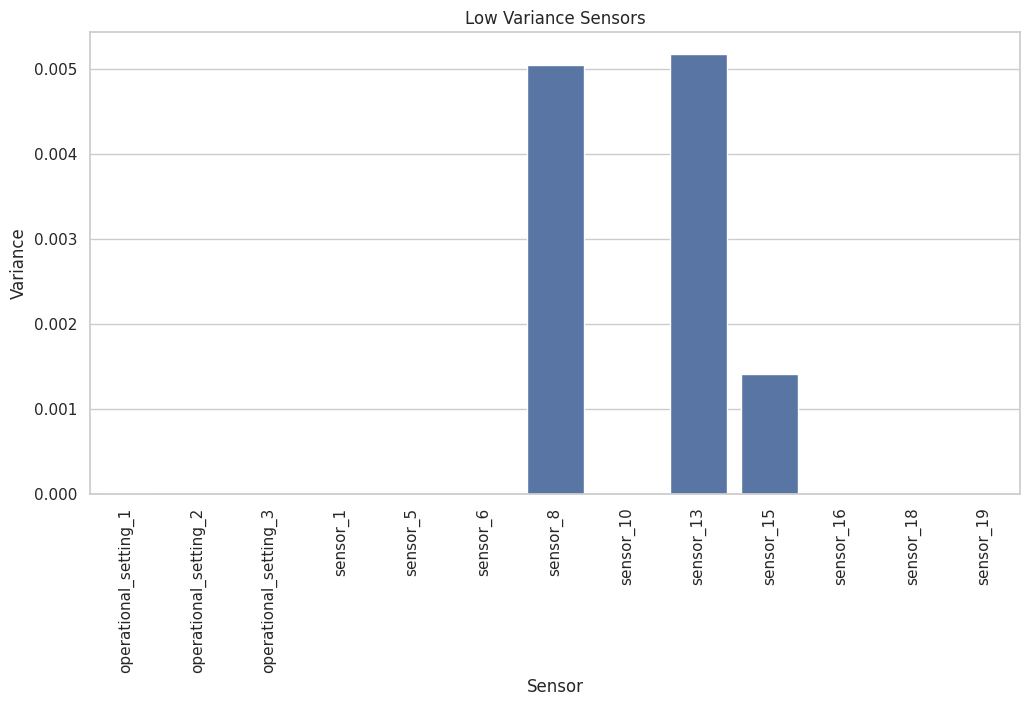

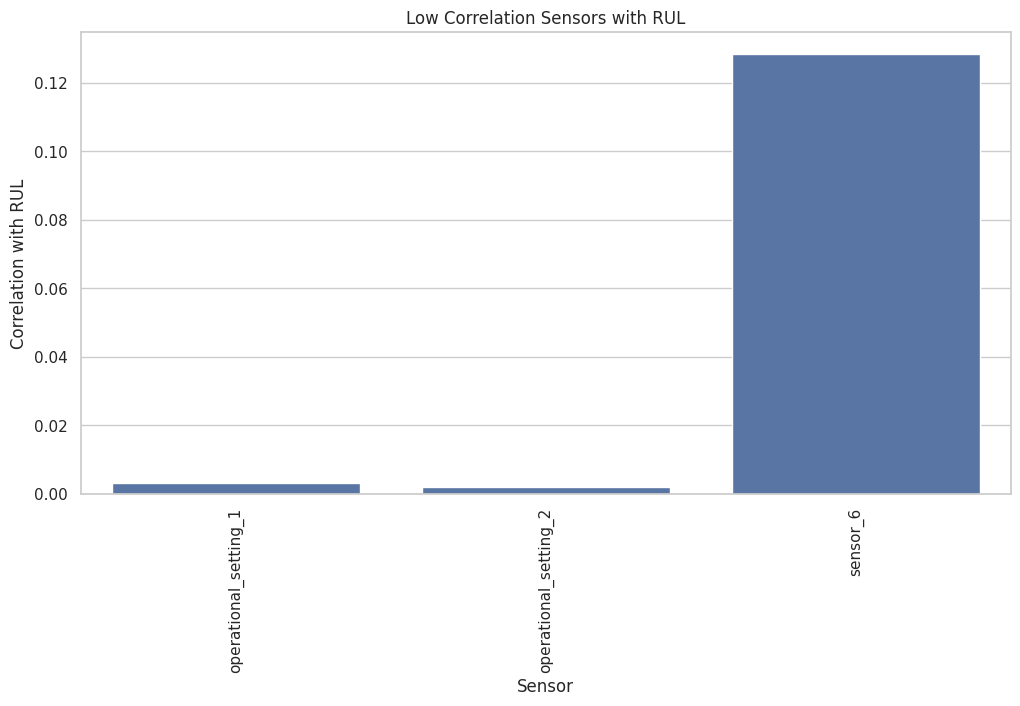

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set thresholds
variance_threshold = 0.01
covariance_threshold = 0.1
correlation_threshold = 0.3

# Calculate variance for each sensor (excluding 'engine_id' and 'cycle')
feature_columns = [col for col in train_df.columns if col not in ['engine_id', 'cycle']]
variance = train_vis[feature_columns].var()

# Calculate covariance between each sensor and RUL
covariance = train_vis[feature_columns + ['RUL']].cov()

# Calculate correlation between each sensor and RUL
correlation = train_vis[feature_columns + ['RUL']].corr()

# Check and list features that don't meet the thresholds
non_compliant_features = []

# Check variance
for feature in variance.index:
    if variance[feature] < variance_threshold:
        non_compliant_features.append(f"Low Variance: {feature} (Variance: {variance[feature]})")

# Check covariance with RUL
for feature in covariance.index:
    if abs(covariance.loc[feature, 'RUL']) < covariance_threshold:
        non_compliant_features.append(f"Low Covariance: {feature} (Covariance with RUL: {covariance.loc[feature, 'RUL']})")

# Check correlation with RUL
for feature in correlation.index:
    if abs(correlation.loc[feature, 'RUL']) < correlation_threshold:
        non_compliant_features.append(f"Low Correlation: {feature} (Correlation with RUL: {correlation.loc[feature, 'RUL']})")

# Print out the features that don't meet the thresholds
if non_compliant_features:
    print("\nFeatures that do not meet the thresholds:")
    for feature in non_compliant_features:
        print(feature)
else:
    print("\nAll features meet the thresholds!")

# Step 1: Identify low variance sensors
low_variance_sensors = variance[variance < variance_threshold].index.tolist()

# Step 2: Identify low correlation sensors with RUL
low_correlation_sensors = correlation[correlation['RUL'].abs() < correlation_threshold].index.tolist()

# Step 3: Plot low variance sensors
plt.figure(figsize=(12, 6))
sns.barplot(x=low_variance_sensors, y=variance[low_variance_sensors])
plt.title("Low Variance Sensors")
plt.xlabel("Sensor")
plt.ylabel("Variance")
plt.xticks(rotation=90)
plt.show()

# Step 4: Plot low correlation sensors with RUL
plt.figure(figsize=(12, 6))
sns.barplot(x=low_correlation_sensors, y=correlation.loc[low_correlation_sensors, 'RUL'].abs())
plt.title("Low Correlation Sensors with RUL")
plt.xlabel("Sensor")
plt.ylabel("Correlation with RUL")
plt.xticks(rotation=90)
plt.show()


Looking at the graph of features/sensors with low correlation and low Variance we will be looking to remove sensors_1,6,5,16,18,19 along with Operation_settings_3. While we could remove operation_settings_2 and 1 we will be keeping operation_settings_1.

##Cleaned dataset

In [16]:
# Features to remove
features_to_remove = [
    'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19',
    'operational_setting_2', 'operational_setting_3'
]

cleaned_train_df = train_df.drop(columns=features_to_remove)
cleaned_test_df = test_df.drop(columns=features_to_remove)

# checking the columns
print("Cleaned training data columns:", cleaned_train_df.columns)
print("Cleaned test data columns:", cleaned_test_df.columns)


Cleaned training data columns: Index(['engine_id', 'cycle', 'operational_setting_1', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21'],
      dtype='str')
Cleaned test data columns: Index(['engine_id', 'cycle', 'operational_setting_1', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21'],
      dtype='str')


###Normalization

In [17]:
from sklearn.preprocessing import StandardScaler

# Define feature columns (everything except 'engine_id' and 'cycle')
feature_columns = [col for col in cleaned_train_df.columns if col not in ['engine_id', 'cycle']]

# Initialize StandardScaler
specified_scaler = StandardScaler()

# Fit and transform the training data (normalize it)
normalized_train_df = cleaned_train_df.copy()
normalized_train_df[feature_columns] = specified_scaler.fit_transform(cleaned_train_df[feature_columns])

# Add the RUL column to normalized_train_df
max_cycles_normalized_train = normalized_train_df.groupby("engine_id")["cycle"].max()
normalized_train_df["RUL"] = normalized_train_df.apply(
    lambda row: max_cycles_normalized_train[row["engine_id"]] - row["cycle"],
    axis=1
)

# Transform the test data (use the same scaler as training data)
normalized_test_df = cleaned_test_df.copy()
normalized_test_df[feature_columns] = specified_scaler.transform(cleaned_test_df[feature_columns])

# Add the RUL column to normalized_test_df
# First, get the maximum cycle for each engine in the test data
max_cycles_test_data = normalized_test_df.groupby("engine_id")["cycle"].max().reset_index()
max_cycles_test_data.columns = ["engine_id", "max_test_cycle"]

# Merge the RUL_end from rul_test with max_cycles_test_data to align by engine_id
# rul_test is 0-indexed, so we map its index + 1 to engine_id
rul_test_indexed = rul_test.copy()
rul_test_indexed["engine_id"] = rul_test_indexed.index + 1
max_cycles_test_data = pd.merge(max_cycles_test_data, rul_test_indexed, on="engine_id", how="left")

# Merge this information back into normalized_test_df
normalized_test_df = pd.merge(
    normalized_test_df,
    max_cycles_test_data[['engine_id', 'max_test_cycle', 'RUL_end']],
    on='engine_id',
    how='left'
)

# Calculate the RUL for each row in the test set:
RUL_for_each_cycle = normalized_test_df["RUL_end"] + \
                     (normalized_test_df["max_test_cycle"] - normalized_test_df["cycle"])
normalized_test_df["RUL"] = RUL_for_each_cycle

# Drop temporary columns used for RUL calculation
normalized_test_df.drop(columns=['max_test_cycle', 'RUL_end'], inplace=True)

# Verify normalization
print("Normalized training data (head):")
print(normalized_train_df.head())
print("\nNot-normalized training data (head):")
print(cleaned_train_df.head())

print("\nNormalized test data (head):")
print(normalized_test_df.head())

Normalized training data (head):
   engine_id  cycle  operational_setting_1  sensor_2  sensor_3  sensor_4  \
0          1      1              -0.315980 -1.721725 -0.134255 -0.925936   
1          1      2               0.872722 -1.061780  0.211528 -0.643726   
2          1      3              -1.961874 -0.661813 -0.413166 -0.525953   
3          1      4               0.324090 -0.661813 -1.261314 -0.784831   
4          1      5              -0.864611 -0.621816 -1.251528 -0.301518   

   sensor_7  sensor_8  sensor_9  sensor_11  sensor_12  sensor_13  sensor_14  \
0  1.121141 -0.516338 -0.862813  -0.266467   0.334262  -1.058890  -0.269071   
1  0.431930 -0.798093 -0.958818  -0.191583   1.174899  -0.363646  -0.642845   
2  1.008155 -0.234584 -0.557139  -1.015303   1.364721  -0.919841  -0.551629   
3  1.222827  0.188048 -0.713826  -1.539489   1.961302  -0.224597  -0.520176   
4  0.714393 -0.516338 -0.457059  -0.977861   1.052871  -0.780793  -0.521748   

   sensor_15  sensor_17  sensor_20 

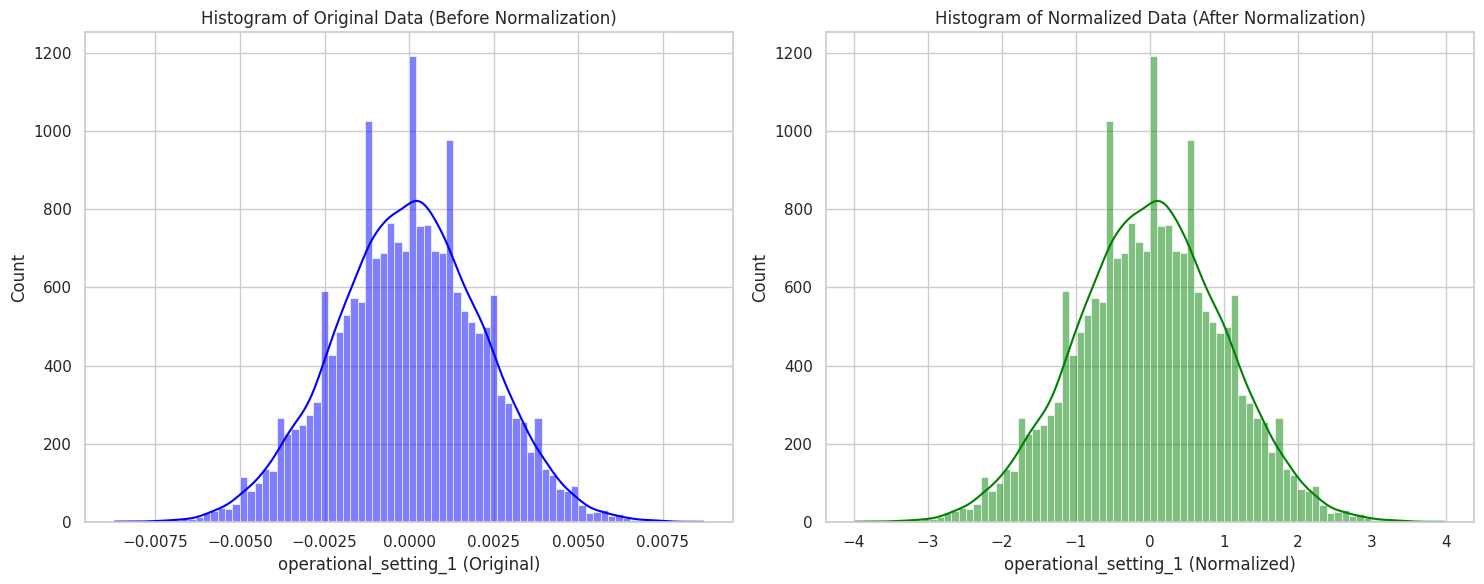

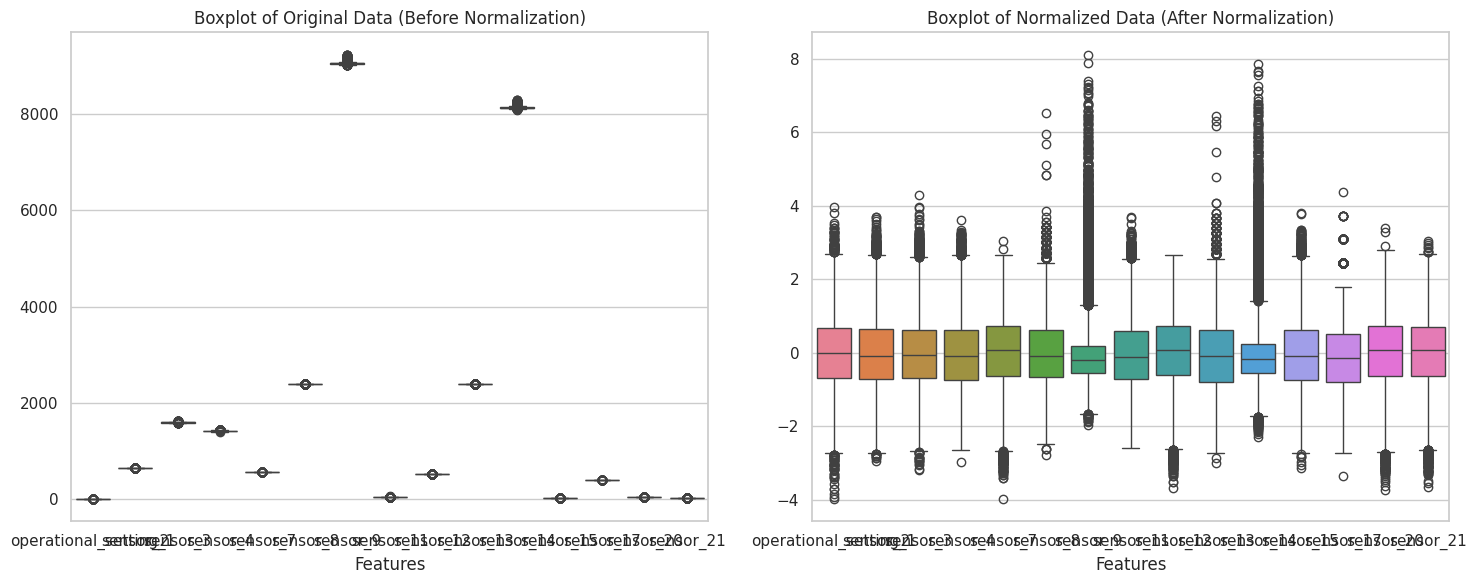

In [18]:
# Plot histograms for the first few features before and after normalization
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Before normalization (raw data)
axes[0].set_title("Histogram of Original Data (Before Normalization)")
sns.histplot(cleaned_train_df[feature_columns[0]], kde=True, ax=axes[0], color='blue')
axes[0].set_xlabel(f'{feature_columns[0]} (Original)')

# After normalization
axes[1].set_title("Histogram of Normalized Data (After Normalization)")
sns.histplot(normalized_train_df[feature_columns[0]], kde=True, ax=axes[1], color='green')
axes[1].set_xlabel(f'{feature_columns[0]} (Normalized)')

plt.tight_layout()
plt.show()

# Plot boxplots for the first few features before and after normalization
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Before normalization (raw data)
sns.boxplot(data=cleaned_train_df[feature_columns], ax=axes[0])
axes[0].set_title("Boxplot of Original Data (Before Normalization)")
axes[0].set_xlabel('Features')

# After normalization
sns.boxplot(data=normalized_train_df[feature_columns], ax=axes[1])
axes[1].set_title("Boxplot of Normalized Data (After Normalization)")
axes[1].set_xlabel('Features')

plt.tight_layout()
plt.show()


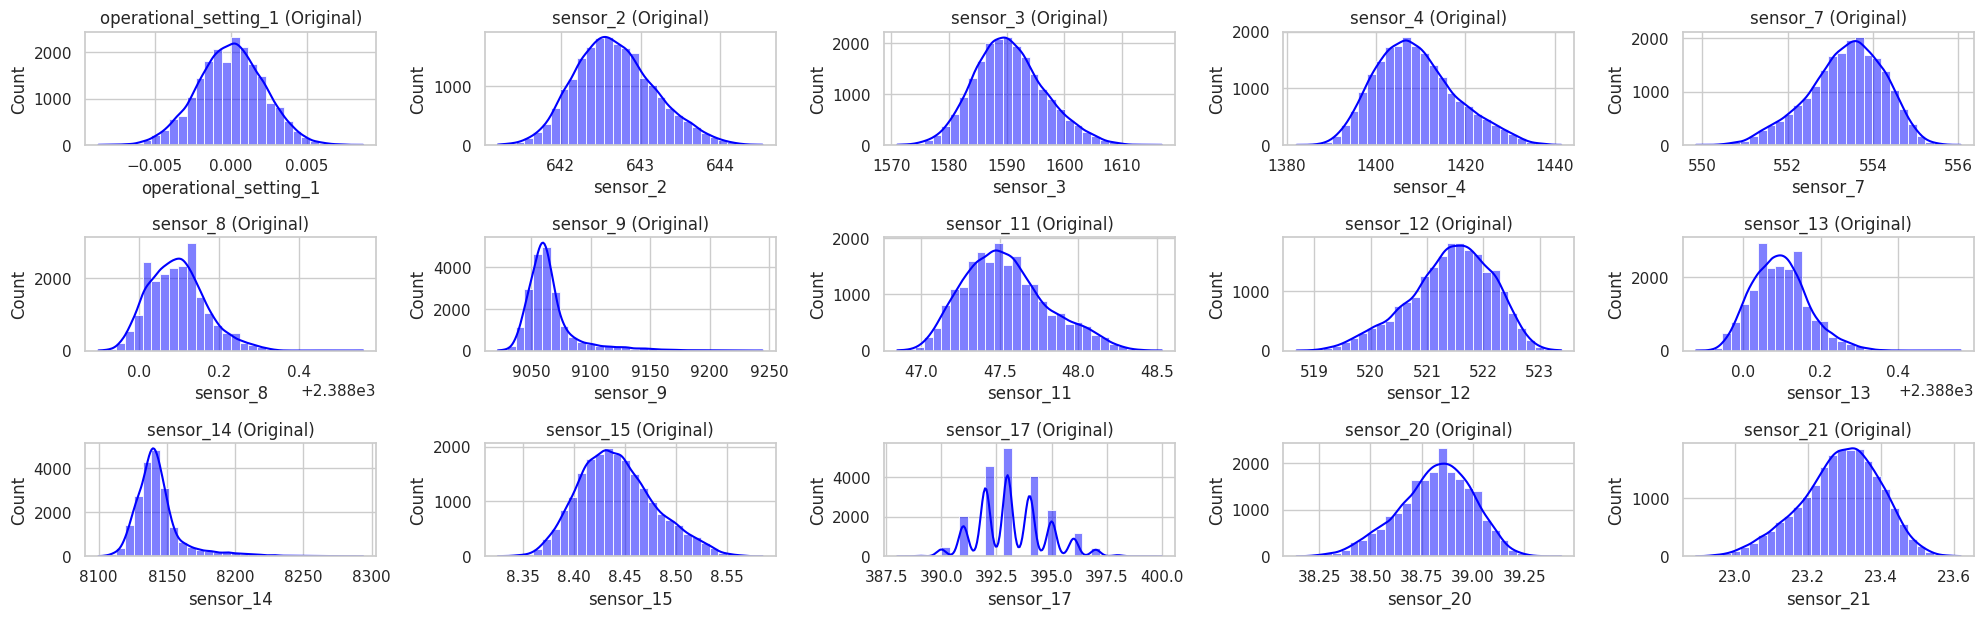

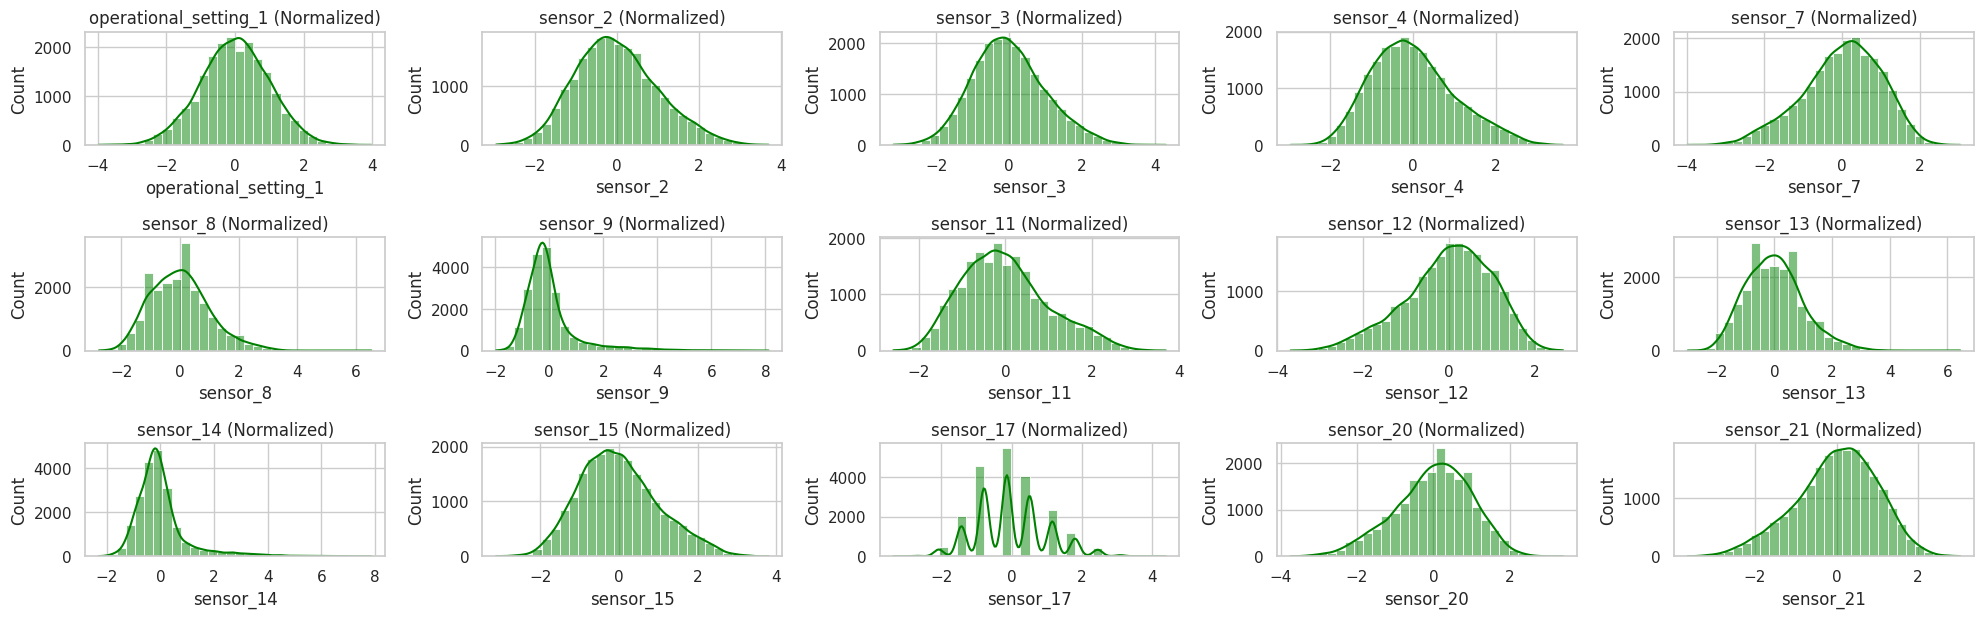

In [19]:
# Plot histograms for all features before and after normalization
plt.figure(figsize=(20, 12))

# Before normalization (raw data)
for i, feature in enumerate(feature_columns):
    plt.subplot(6, 5, i+1)  # Adjust the grid for 21 features (6 rows, 5 columns)
    sns.histplot(cleaned_train_df[feature], kde=True, bins=30, color='blue')
    plt.title(f"{feature} (Original)")
    plt.xlabel(f'{feature}')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# After normalization
plt.figure(figsize=(20, 12))
for i, feature in enumerate(feature_columns):
    plt.subplot(6, 5, i+1)  # Adjust the grid for 21 features (6 rows, 5 columns)
    sns.histplot(normalized_train_df[feature], kde=True, bins=30, color='green')
    plt.title(f"{feature} (Normalized)")
    plt.xlabel(f'{feature}')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


##Windowing For LSTM

In [20]:
def create_windows(df, window_size=30):
    """
    Create windowed data for all engines in the dataset with a given window size.
    Each engine's cycles are treated independently.
    """
    X = []
    y = []

    # Loop through each engine in the dataset
    for engine_id in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == engine_id].sort_values("cycle")

        # Only proceed if the engine has enough cycles
        if len(engine_data) < window_size:
            continue

        # Sliding window over cycles for this engine
        for i in range(window_size - 1, len(engine_data)):
            window = engine_data.iloc[i - window_size + 1:i + 1]  # Get the window of data
            X.append(window[feature_columns].values)  # Extract the sensor values
            y.append(engine_data.iloc[i]["RUL"])  # The RUL for this cycle (target)

    # Convert to numpy arrays for model input
    X = np.array(X)
    y = np.array(y)

    return X, y

# Create windowed data for all engines with window size = 30
X_train, y_train = create_windows(normalized_train_df, window_size=30)

# Check the shape of the windowed data
print("Windowed training data shape:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# windowing for the test set (same window size = 30)
X_test, y_test = create_windows(normalized_test_df, window_size=30)

# Check the shape of the windowed test data
print("Windowed test data shape:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Windowed training data shape:
X_train shape: (17731, 30, 15)
y_train shape: (17731,)
Windowed test data shape:
X_test shape: (10196, 30, 15)
y_test shape: (10196,)


#Model Selection And Sanity Testing

## Random Forest

###Imports

In [21]:
# Imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

###Cap RUL at 125 cycles

In [22]:
# Cap RUL at 125 cycles — a standard practice for FD001.
# Early cycles have near-identical sensor readings regardless
# of total engine life, so uncapped RUL values add noise
# without useful signal.

RUL_CAP = 125

normalized_train_df["RUL"] = normalized_train_df["RUL"].clip(upper=RUL_CAP)
normalized_test_df["RUL"]  = normalized_test_df["RUL"].clip(upper=RUL_CAP)

print(f"RUL capped at {RUL_CAP} cycles.")
print(f"Train RUL range: {normalized_train_df['RUL'].min():.0f} – {normalized_train_df['RUL'].max():.0f}")
print(f"Test  RUL range: {normalized_test_df['RUL'].min():.0f} – {normalized_test_df['RUL'].max():.0f}")

RUL capped at 125 cycles.
Train RUL range: 0 – 125
Test  RUL range: 7 – 125


### Split Data

In [23]:
# We split by engine ID — NOT by row — to prevent data leakage.
# Rows from the same engine are temporally correlated, so a
# random row-split would let the model "see" future cycles
# during training.

np.random.seed(42)

all_engine_ids = normalized_train_df["engine_id"].unique()
np.random.shuffle(all_engine_ids)

split_idx    = int(len(all_engine_ids) * 0.8)
train_engines = all_engine_ids[:split_idx]
val_engines   = all_engine_ids[split_idx:]

train_split = normalized_train_df[normalized_train_df["engine_id"].isin(train_engines)]
val_split   = normalized_train_df[normalized_train_df["engine_id"].isin(val_engines)]

print(f"Engines in training split:   {len(train_engines)}")
print(f"Engines in validation split: {len(val_engines)}")
print(f"Training rows:   {len(train_split)}")
print(f"Validation rows: {len(val_split)}")

Engines in training split:   80
Engines in validation split: 20
Training rows:   16340
Validation rows: 4291


In [24]:
# RF takes flat per-cycle feature vectors (no sequences needed).
# We drop engine_id and cycle — they are identifiers, not signals.

feature_cols = [col for col in normalized_train_df.columns
                if col not in ["engine_id", "cycle", "RUL"]]

X_train_rf = train_split[feature_cols].values
y_train_rf = train_split["RUL"].values

X_val_rf = val_split[feature_cols].values
y_val_rf  = val_split["RUL"].values

X_test_rf = normalized_test_df[feature_cols].values
y_test_rf  = normalized_test_df["RUL"].values

print(f"Feature columns used: {feature_cols}")
print(f"X_train shape: {X_train_rf.shape}")
print(f"X_val   shape: {X_val_rf.shape}")
print(f"X_test  shape: {X_test_rf.shape}")

Feature columns used: ['operational_setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
X_train shape: (16340, 15)
X_val   shape: (4291, 15)
X_test  shape: (13096, 15)


In [25]:
# Calculate metrics
def compute_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f"[{label}]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
    return mae, rmse, r2

###SANITY CHECK: Default Random Forest

In [26]:
# Before tuning, verify the end-to-end pipeline works with
# default hyperparameters. If MAE is reasonable, preprocessing
# is functioning correctly.

print("=" * 50)
print("SANITY CHECK: Default Random Forest")
print("=" * 50)

rf_default = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_default.fit(X_train_rf, y_train_rf)

y_pred_default = rf_default.predict(X_val_rf)
compute_metrics(y_val_rf, y_pred_default, label="Default RF — Validation")

SANITY CHECK: Default Random Forest
[Default RF — Validation]  MAE=14.146  RMSE=19.701  R²=0.7748


(14.145819156373806, 19.70147069843247, 0.7748202877741406)

Default RF give us a decent result

###Hyperparameter grid search

In [27]:
# We perform a manual grid search (instead of GridSearchCV) so
# we can log every combination clearly for the report table.
# Varying: n_estimators, max_depth, min_samples_split.

param_grid = {
    "n_estimators":     [50, 100, 200],
    "max_depth":        [10, 20, None],
    "min_samples_split":[2, 5, 10],
}

results = []

print("Running hyperparameter grid search...")
print(f"Total combinations: {len(list(ParameterGrid(param_grid)))}\n")

for params in ParameterGrid(param_grid):
    rf = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    rf.fit(X_train_rf, y_train_rf)
    y_pred = rf.predict(X_val_rf)
    mae, rmse, r2 = compute_metrics(y_val_rf, y_pred)

    results.append({
        "n_estimators":     params["n_estimators"],
        "max_depth":        str(params["max_depth"]),  # None → string for display
        "min_samples_split":params["min_samples_split"],
        "MAE":  round(mae,  3),
        "RMSE": round(rmse, 3),
        "R2":   round(r2,   4),
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n── Hyperparameter Results (sorted by RMSE) ──")
print(results_df.to_string(index=False))


Running hyperparameter grid search...
Total combinations: 27


── Hyperparameter Results (sorted by RMSE) ──
 n_estimators max_depth  min_samples_split    MAE   RMSE     R2
          200        20                 10 14.014 19.579 0.7776
          200        10                 10 14.060 19.584 0.7775
          200        10                  5 14.059 19.590 0.7774
          200      None                 10 14.070 19.592 0.7773
          200        10                  2 14.058 19.595 0.7773
          200        20                  5 14.022 19.605 0.7770
          100        10                 10 14.066 19.620 0.7767
          200      None                  2 14.108 19.623 0.7766
          200        20                  2 14.043 19.626 0.7765
          100        10                  2 14.062 19.627 0.7765
          100        10                  5 14.070 19.630 0.7764
          100        20                 10 14.032 19.634 0.7764
          200      None                  5 14.101 19.635 0.

results:
- More trees in the forest (n_estimators) = better results
- max_depth has little effect on the results
- min_sample_split has the biggest effect on the results
- default RF = [MAE=14.146  RMSE=19.701  R²=0.7748]
- After trying to tune the RF we find that we have hit a wall for RF. We will need a more complex model if we want to get better results.

###Best Hyperparameters RF

In [28]:
# Retrain with the best hyperparameters found above, then
# evaluate on the held-out validation set and the test set.

best_row    = results_df.iloc[0]
best_params = {
    "n_estimators":     int(best_row["n_estimators"]),
    "max_depth":        None if best_row["max_depth"] == "None"
                             else int(best_row["max_depth"]),
    "min_samples_split":int(best_row["min_samples_split"]),
}

print("\n── Best Hyperparameters ──")
print(best_params)

rf_best = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
rf_best.fit(X_train_rf, y_train_rf)

y_pred_val  = rf_best.predict(X_val_rf)
y_pred_test = rf_best.predict(X_test_rf)

print("\n── Best RF Performance ──")
compute_metrics(y_val_rf,  y_pred_val,  label="Validation")
compute_metrics(y_test_rf, y_pred_test, label="Test       ")



── Best Hyperparameters ──
{'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 10}

── Best RF Performance ──
[Validation]  MAE=14.014  RMSE=19.579  R²=0.7776
[Test       ]  MAE=12.378  RMSE=17.180  R²=0.6120


(12.37792024389753, 17.17989251062877, 0.6119591888813085)

In [29]:
# Model Complexity Metrics
# Required by the rubric: report trainable parameters,
# inference time, and estimated FLOPs for fair model comparison.

n_trees      = rf_best.n_estimators
total_nodes  = sum(tree.tree_.node_count for tree in rf_best.estimators_)
leaf_nodes   = sum(tree.tree_.n_node_samples[tree.tree_.children_left == -1].shape[0]
                   for tree in rf_best.estimators_)

# Inference time (average over 100 runs on the test set)
times = []
for _ in range(100):
    t0 = time.perf_counter()
    rf_best.predict(X_test_rf)
    times.append(time.perf_counter() - t0)
avg_inference_ms = np.mean(times) * 1000

# FLOPs estimate: each prediction traverses one path per tree.
# Average depth ≈ log2(total_nodes/n_trees). Each node = 1 comparison.
avg_depth    = np.mean([tree.tree_.max_depth for tree in rf_best.estimators_])
n_test_rows  = X_test_rf.shape[0]
flops_approx = n_test_rows * n_trees * avg_depth  # comparisons per prediction

print("── Complexity Metrics ──")
print(f"Number of trees:          {n_trees}")
print(f"Total nodes (all trees):  {total_nodes:,}")
print(f"Avg tree depth:           {avg_depth:.1f}")
print(f"Avg inference time:       {avg_inference_ms:.2f} ms  ({n_test_rows} samples)")
print(f"Estimated FLOPs (test):   {flops_approx:,.0f}")

── Complexity Metrics ──
Number of trees:          200
Total nodes (all trees):  680,460
Avg tree depth:           20.0
Avg inference time:       48.33 ms  (13096 samples)
Estimated FLOPs (test):   52,384,000


###Figure 1 — Feature Importances

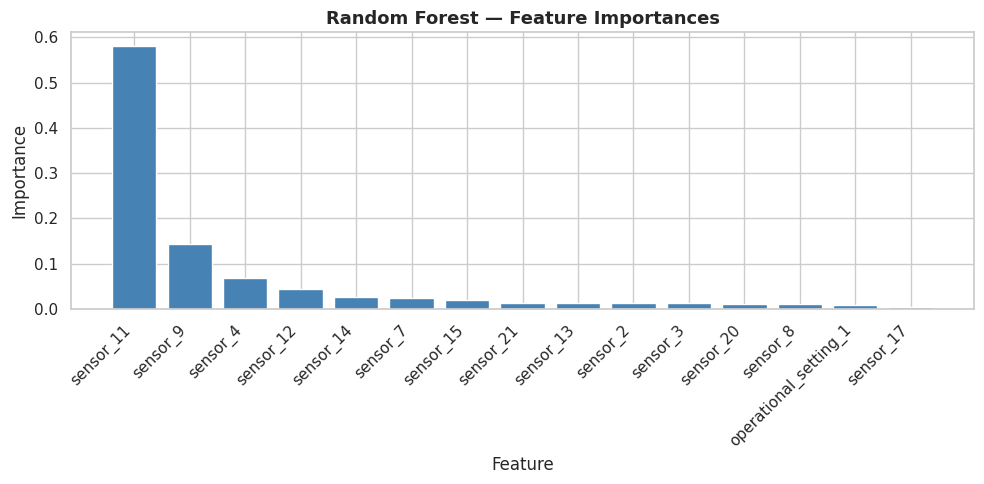

Saved: rf_feature_importance.png


In [30]:
# Figure 1 — Feature Importances
importances = rf_best.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(feature_cols)),
       importances[sorted_idx],
       color="steelblue", edgecolor="white")
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels([feature_cols[i] for i in sorted_idx], rotation=45, ha="right")
ax.set_title("Random Forest — Feature Importances", fontsize=13, fontweight="bold")
ax.set_ylabel("Importance")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()
print("Saved: rf_feature_importance.png")

###Figure 3 — Residual Distribution RF

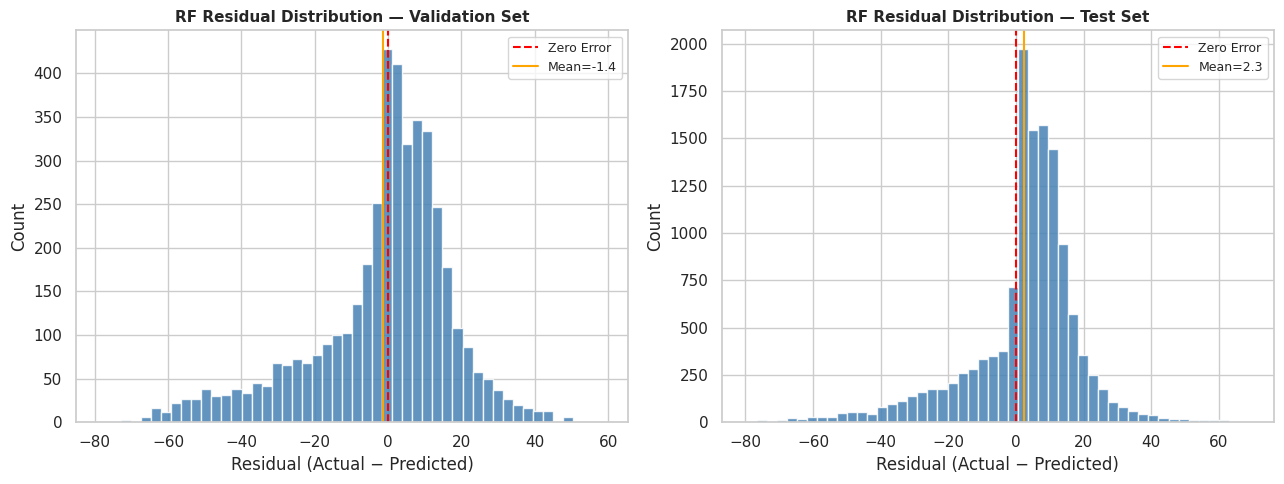

Saved: rf_residuals.png


In [31]:
# Figure 3 — Residual Distribution
residuals_val  = y_val_rf  - y_pred_val
residuals_test = y_test_rf - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, residuals, title in zip(
        axes,
        [residuals_val, residuals_test],
        ["Validation Set", "Test Set"]):

    ax.hist(residuals, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Error")
    ax.axvline(residuals.mean(), color="orange", linestyle="-",
               linewidth=1.5, label=f"Mean={residuals.mean():.1f}")
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Count")
    ax.set_title(f"RF Residual Distribution — {title}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("rf_residuals.png", dpi=150)
plt.show()
print("Saved: rf_residuals.png")


The x-axis shows the residual, which is Actual RUL minus Predicted RUL. So:

- A bar at 0 means the model predicted perfectly
- A bar at +20 means the model predicted 20 cycles too low (underestimated)
- A bar at -20 means the model predicted 20 cycles too high (overestimated)

### Figure 4 — Hyperparameter RMSE Heatmap

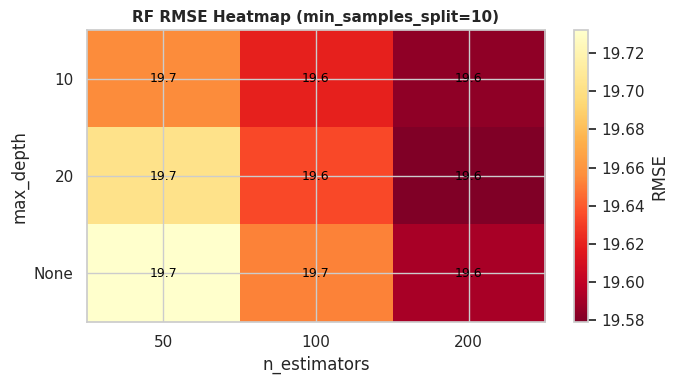

Saved: rf_hparam_heatmap.png


In [32]:
# Figure 4 — Hyperparameter RMSE Heatmap
# Visualize how n_estimators and max_depth interact for RMSE.
# Fix min_samples_split to its best value for clarity.

best_mss = int(best_row["min_samples_split"])
heatmap_df = results_df[results_df["min_samples_split"] == best_mss].copy()

pivot = heatmap_df.pivot(index="max_depth", columns="n_estimators", values="RMSE")

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="YlOrRd_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("n_estimators")
ax.set_ylabel("max_depth")
ax.set_title(f"RF RMSE Heatmap (min_samples_split={best_mss})", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, label="RMSE")

# Annotate cells
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.1f}",
                ha="center", va="center", fontsize=9, color="black")

plt.tight_layout()
plt.savefig("rf_hparam_heatmap.png", dpi=150)
plt.show()
print("Saved: rf_hparam_heatmap.png")


### RF summary

In [33]:
# Final Summary Table
mae_v,  rmse_v,  r2_v  = compute_metrics(y_val_rf,  y_pred_val)
mae_t,  rmse_t,  r2_t  = compute_metrics(y_test_rf, y_pred_test)

# Save RF-specific aliases so they persist after MLP/LSTM sections overwrite mae_v/rmse_v/r2_v
rf_mae_v,  rf_rmse_v,  rf_r2_v  = mae_v,  rmse_v,  r2_v

summary = pd.DataFrame({
    "Split":      ["Validation", "Test"],
    "MAE":        [round(mae_v,  3), round(mae_t,  3)],
    "RMSE":       [round(rmse_v, 3), round(rmse_t, 3)],
    "R²":         [round(r2_v,   4), round(r2_t,   4)],
    "Inference (ms)": [f"{avg_inference_ms:.2f}", "—"],
    "FLOPs (est)":    ["—", f"{flops_approx:,.0f}"],
})

print("══ Random Forest Baseline — Final Results ══")
print(summary.to_string(index=False))


══ Random Forest Baseline — Final Results ══
     Split    MAE   RMSE     R² Inference (ms) FLOPs (est)
Validation 14.014 19.579 0.7776          48.33           —
      Test 12.378 17.180 0.6120              —  52,384,000


In [34]:
# RF Parameter Count
# For Random Forest, "parameters" are the total number of
# split thresholds and leaf values stored across all trees.
# Each internal node stores 1 threshold, each leaf stores 1 value.

total_internal_nodes = 0
total_leaf_nodes     = 0

for tree in rf_best.estimators_:
    n_nodes    = tree.tree_.node_count
    children_left = tree.tree_.children_left

    # Leaf nodes have no left child (value = -1)
    leaves   = np.sum(children_left == -1)
    internal = n_nodes - leaves

    total_leaf_nodes     += leaves
    total_internal_nodes += internal

# Each internal node stores: feature index + threshold = 2 values
# Each leaf node stores: 1 predicted value
total_rf_params = (total_internal_nodes * 2) + total_leaf_nodes

print("── RF Parameter Equivalent ──")
print(f"Total trees:          {rf_best.n_estimators}")
print(f"Total internal nodes: {total_internal_nodes:,}")
print(f"Total leaf nodes:     {total_leaf_nodes:,}")
print(f"Total parameters:     {total_rf_params:,}")

── RF Parameter Equivalent ──
Total trees:          200
Total internal nodes: 340,130
Total leaf nodes:     340,330
Total parameters:     1,020,590


# Neural Network Model: Multilayer Perceptron (MLP)

###Imports

In [35]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


###Prepare Data for MLP

In [36]:
# Prepare Data for MLP
# MLP uses the same flat per-cycle feature vectors as RF.
# We reuse the same engine-based train/val split from the RF
# section to ensure a fair comparison between models.
# X_train_rf, X_val_rf, X_test_rf, y_train_rf, y_val_rf,
# y_test_rf are already defined from the RF section.

def to_tensors(X, y):
    """Convert numpy arrays to PyTorch float tensors."""
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1))

X_train_t, y_train_t = to_tensors(X_train_rf, y_train_rf)
X_val_t,   y_val_t   = to_tensors(X_val_rf,   y_val_rf)
X_test_t,  y_test_t  = to_tensors(X_test_rf,  y_test_rf)

print(f"Input feature size: {X_train_t.shape[1]}")
print(f"Training samples:   {X_train_t.shape[0]}")
print(f"Validation samples: {X_val_t.shape[0]}")
print(f"Test samples:       {X_test_t.shape[0]}")

Input feature size: 15
Training samples:   16340
Validation samples: 4291
Test samples:       13096


###MLP Architecture

In [37]:
# MLP Architecture
class MLP(nn.Module):
    """
    Multilayer Perceptron for RUL regression.

    Architecture:
        Input → FC(128) → BN → ReLU → Dropout
              → FC(64)  → BN → ReLU → Dropout
              → FC(32)  → BN → ReLU → Dropout
              → FC(1)   (output, no activation for regression)

    BatchNorm stabilizes training by normalizing layer inputs.
    Dropout prevents overfitting by randomly zeroing neurons.
    ReLU avoids vanishing gradients common in deep networks.
    """
    def __init__(self, input_size, hidden_layers, dropout_rate):
        """
        Args:
            input_size   : number of input features
            hidden_layers: list of neuron counts e.g. [128, 64, 32]
            dropout_rate : fraction of neurons to drop e.g. 0.2
        """
        super(MLP, self).__init__()

        layers = []
        in_size = input_size

        for out_size in hidden_layers:
            layers.append(nn.Linear(in_size, out_size))
            layers.append(nn.BatchNorm1d(out_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_rate))
            in_size = out_size

        # Output layer — single neuron, no activation (regression)
        layers.append(nn.Linear(in_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


###Training and Evaluation Helpers

In [38]:
# Training and Evaluation Helpers
def train_one_epoch(model, loader, optimizer, criterion):
    """Run one full pass over the training data."""
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


def evaluate(model, X_tensor, y_tensor):
    """Return MAE, RMSE, R² and predictions for a dataset."""
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor.to(device)).cpu().numpy().flatten()
    y_true = y_tensor.numpy().flatten()
    mae  = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2   = r2_score(y_true, preds)
    return mae, rmse, r2, preds


def count_parameters(model):
    """Count total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


###Sanity Check — Default MLP

In [39]:
# Sanity Check — Default MLP
# Train a single default MLP to verify the pipeline works
# before running the full hyperparameter search.

print("=" * 50)
print("SANITY CHECK: Default MLP")
print("=" * 50)

input_size = X_train_t.shape[1]

sanity_model = MLP(
    input_size    = input_size,
    hidden_layers = [128, 64, 32],
    dropout_rate  = 0.2
).to(device)

sanity_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256, shuffle=True
)

sanity_optimizer = torch.optim.Adam(sanity_model.parameters(), lr=1e-3)
sanity_criterion = nn.MSELoss()

# Train for 50 epochs as a quick sanity check
for epoch in range(50):
    train_loss = train_one_epoch(
        sanity_model, sanity_loader,
        sanity_optimizer, sanity_criterion
    )

mae, rmse, r2, _ = evaluate(sanity_model, X_val_t, y_val_t)
print(f"[Default MLP — Validation]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
print(f"Trainable parameters: {count_parameters(sanity_model):,}")


SANITY CHECK: Default MLP
[Default MLP — Validation]  MAE=14.943  RMSE=19.499  R²=0.7794
Trainable parameters: 12,865


###Hyperparameter Search

In [40]:
# Hyperparameter Search
# Search over architecture width, learning rate, and dropout.
# Each combination is trained for 100 epochs with early stopping.
# We log all results for the report table.

EPOCHS      = 100
BATCH_SIZE  = 256
PATIENCE    = 10   # early stopping patience

param_grid = {
    "hidden_layers": [[128, 64, 32], [64, 128, 64], [256, 128, 64]],
    "learning_rate": [1e-3, 5e-4],
    "dropout_rate":  [0.2, 0.3,0.1],
}

# Build all combinations manually
from itertools import product

all_configs = [
    {"hidden_layers": hl, "learning_rate": lr, "dropout_rate": dr}
    for hl, lr, dr in product(
        param_grid["hidden_layers"],
        param_grid["learning_rate"],
        param_grid["dropout_rate"]
    )
]

print(f"Total hyperparameter combinations: {len(all_configs)}\n")

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True
)

criterion = nn.MSELoss()
hparam_results = []

for i, config in enumerate(all_configs):
    hl = config["hidden_layers"]
    lr = config["learning_rate"]
    dr = config["dropout_rate"]

    model     = MLP(input_size, hl, dr).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_rmse  = float("inf")
    patience_count = 0

    for epoch in range(EPOCHS):
        train_one_epoch(model, train_loader, optimizer, criterion)
        _, val_rmse, _, _ = evaluate(model, X_val_t, y_val_t)

        if val_rmse < best_val_rmse:
            best_val_rmse  = val_rmse
            patience_count = 0
            # Save best weights
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break

    # Restore best weights and compute full metrics
    model.load_state_dict(best_weights)
    mae, rmse, r2, _ = evaluate(model, X_val_t, y_val_t)
    n_params = count_parameters(model)

    hparam_results.append({
        "hidden_layers": str(hl),
        "learning_rate": lr,
        "dropout_rate":  dr,
        "MAE":           round(mae,  3),
        "RMSE":          round(rmse, 3),
        "R2":            round(r2,   4),
        "params":        n_params,
        "stopped_epoch": epoch + 1,
        "_model":        model,        # keep reference for best model
        "_weights":      best_weights,
    })

    print(f"[{i+1:2d}/{len(all_configs)}] hl={str(hl):<18} lr={lr}  "
          f"dr={dr}  RMSE={rmse:.3f}  R²={r2:.4f}  "
          f"epochs={epoch+1}")

# Sort and display results table
results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if not k.startswith("_")}
     for r in hparam_results]
).sort_values("RMSE")

print("\n── Hyperparameter Results (sorted by RMSE) ──")
print(results_df.to_string(index=False))


Total hyperparameter combinations: 18

[ 1/18] hl=[128, 64, 32]      lr=0.001  dr=0.2  RMSE=19.050  R²=0.7895  epochs=53
[ 2/18] hl=[128, 64, 32]      lr=0.001  dr=0.3  RMSE=19.085  R²=0.7887  epochs=61
[ 3/18] hl=[128, 64, 32]      lr=0.001  dr=0.1  RMSE=19.222  R²=0.7857  epochs=42
[ 4/18] hl=[128, 64, 32]      lr=0.0005  dr=0.2  RMSE=19.148  R²=0.7873  epochs=78
[ 5/18] hl=[128, 64, 32]      lr=0.0005  dr=0.3  RMSE=19.131  R²=0.7877  epochs=96
[ 6/18] hl=[128, 64, 32]      lr=0.0005  dr=0.1  RMSE=19.293  R²=0.7841  epochs=70
[ 7/18] hl=[64, 128, 64]      lr=0.001  dr=0.2  RMSE=19.132  R²=0.7876  epochs=29
[ 8/18] hl=[64, 128, 64]      lr=0.001  dr=0.3  RMSE=19.010  R²=0.7904  epochs=50
[ 9/18] hl=[64, 128, 64]      lr=0.001  dr=0.1  RMSE=19.081  R²=0.7888  epochs=29
[10/18] hl=[64, 128, 64]      lr=0.0005  dr=0.2  RMSE=19.034  R²=0.7898  epochs=63
[11/18] hl=[64, 128, 64]      lr=0.0005  dr=0.3  RMSE=19.052  R²=0.7894  epochs=60
[12/18] hl=[64, 128, 64]      lr=0.0005  dr=0.1  RMSE=

Results:
- hidden_layers: the medium architecture is the best
- A higher learning rate 0.0010 converged in 34 epoch beating 0.0005
- Lower dropout 0.2 helps with overfitting beating 0.3 which removes to much info
- most models stop between 30 to 50 epoch before plateauing
- Only used 18,177 parameters vs Rf which used 1,020,590

###Best Model — Full Evaluation

In [41]:
# Best Model — Full Evaluation
best_config = hparam_results[
    results_df.index[0]  # index of best row in original list
]

best_model = best_config["_model"]
best_model.load_state_dict(best_config["_weights"])
best_model.eval()

mae_v,  rmse_v,  r2_v,  y_pred_val_mlp  = evaluate(best_model, X_val_t,  y_val_t)
mae_t,  rmse_t,  r2_t,  y_pred_test_mlp = evaluate(best_model, X_test_t, y_test_t)

print("\n── Best MLP Configuration ──")
print(f"  Hidden layers : {best_config['hidden_layers']}")
print(f"  Learning rate : {best_config['learning_rate']}")
print(f"  Dropout rate  : {best_config['dropout_rate']}")
print(f"  Parameters    : {count_parameters(best_model):,}")
print(f"\n── Best MLP Performance ──")
print(f"  [Validation]  MAE={mae_v:.3f}  RMSE={rmse_v:.3f}  R²={r2_v:.4f}")
print(f"  [Test]        MAE={mae_t:.3f}  RMSE={rmse_t:.3f}  R²={r2_t:.4f}")


── Best MLP Configuration ──
  Hidden layers : [64, 128, 64]
  Learning rate : 0.001
  Dropout rate  : 0.3
  Parameters    : 18,177

── Best MLP Performance ──
  [Validation]  MAE=14.242  RMSE=19.010  R²=0.7904
  [Test]        MAE=13.390  RMSE=17.285  R²=0.6072


###MLP Hyperparameter Heatmap

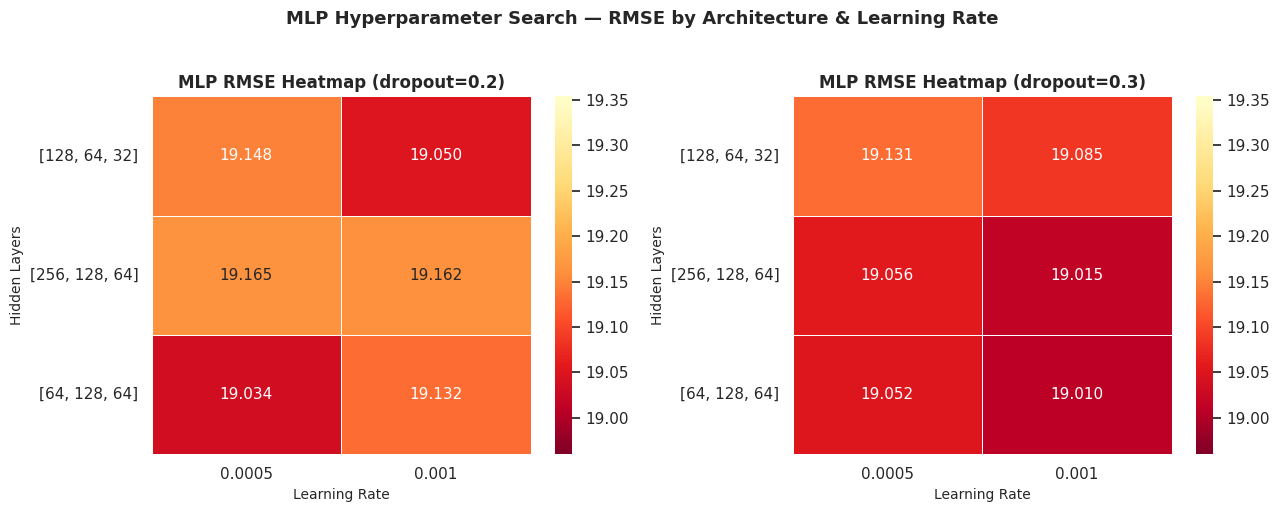

Saved: mlp_hparam_heatmap.png


In [42]:
# MLP Hyperparameter Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# We'll create two heatmaps side by side:
# one for each dropout rate, with learning rate vs architecture on the axes

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, dr in zip(axes, [0.2, 0.3]):
    # Filter results for this dropout rate
    subset = results_df[results_df["dropout_rate"] == dr].copy()

    # Pivot: rows = hidden_layers, cols = learning_rate, values = RMSE
    pivot = subset.pivot(index="hidden_layers",
                         columns="learning_rate",
                         values="RMSE")

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,          # show RMSE values in each cell
        fmt=".3f",           # 3 decimal places
        cmap="YlOrRd_r",     # reversed: green = better (lower RMSE)
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 11},
        vmin=results_df["RMSE"].min() - 0.05,  # shared color scale
        vmax=results_df["RMSE"].max() + 0.05,
    )

    ax.set_title(f"MLP RMSE Heatmap (dropout={dr})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Learning Rate", fontsize=10)
    ax.set_ylabel("Hidden Layers", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle("MLP Hyperparameter Search — RMSE by Architecture & Learning Rate",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("mlp_hparam_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mlp_hparam_heatmap.png")

## Model Evaluation

###Model Complexity Metrics

In [43]:
# Model Complexity Metrics
# Measure inference time and estimate FLOPs for fair
# comparison against RF, MLP, and LSTM in the final report.

# Inference time (average over 100 runs on test set)
times = []
best_model.eval()
with torch.no_grad():
    for _ in range(100):
        t0 = time.perf_counter()
        best_model(X_test_t.to(device))
        times.append(time.perf_counter() - t0)

avg_inference_ms = np.mean(times) * 1000

# FLOPs estimate: for a fully connected layer,
# FLOPs = 2 × input_size × output_size (multiply + add)
# per sample. Sum across all layers × number of test samples.
n_params   = count_parameters(best_model)
hl         = json.loads(best_config["hidden_layers"])
layer_sizes = [input_size] + hl + [1]
flops_per_sample = sum(
    2 * layer_sizes[i] * layer_sizes[i+1]
    for i in range(len(layer_sizes) - 1)
)
total_flops = flops_per_sample * X_test_t.shape[0]

print("── Complexity Metrics ──")
print(f"Trainable parameters:    {n_params:,}")
print(f"FLOPs per sample:        {flops_per_sample:,}")
print(f"Total FLOPs (test set):  {total_flops:,}")
print(f"Avg inference time:      {avg_inference_ms:.2f} ms  "
      f"({X_test_t.shape[0]} samples)")


── Complexity Metrics ──
Trainable parameters:    18,177
FLOPs per sample:        34,816
Total FLOPs (test set):  455,950,336
Avg inference time:      0.94 ms  (13096 samples)


# Long Short-Term Memory (LSTM)

#### Imports

In [44]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from itertools import product

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


###Prepare Windowed Data for LSTM

In [45]:
# Prepare Windowed Data for LSTM
# LSTM requires 3D input: (samples, timesteps, features)
# We use the windowed data already created in preprocessing:
# X_train, y_train from create_windows(normalized_train_df)
#
# IMPORTANT: We must do an engine-based train/val split on the
# WINDOWED data to prevent leakage. We cannot reuse the RF/MLP
# split directly because windowing was done before splitting.
# Instead we re-window each split separately.

feature_cols_lstm = [col for col in normalized_train_df.columns
                     if col not in ["engine_id", "cycle", "RUL"]]

def create_windows_split(df, window_size=30):
    """
    Create windowed sequences per engine.
    Returns X: (samples, timesteps, features), y: (samples,)
    """
    X, y = [], []
    for eid in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == eid].sort_values("cycle")
        if len(engine_data) < window_size:
            continue
        for i in range(window_size - 1, len(engine_data)):
            window = engine_data.iloc[i - window_size + 1: i + 1]
            X.append(window[feature_cols_lstm].values)
            y.append(engine_data.iloc[i]["RUL"])
    return np.array(X), np.array(y)

def to_tensors_3d(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1))

# Engine-based split (same 80/20 engine IDs as RF/MLP)
train_split_lstm = normalized_train_df[
    normalized_train_df["engine_id"].isin(train_engines)]
val_split_lstm   = normalized_train_df[
    normalized_train_df["engine_id"].isin(val_engines)]

def build_lstm_tensors(seq_len):
    """Build train/val/test tensors for a given sequence length."""
    print(f"  Building sequences for seq_len={seq_len}...")
    X_tr, y_tr = create_windows_split(train_split_lstm, seq_len)
    X_vl, y_vl = create_windows_split(val_split_lstm,   seq_len)
    X_te, y_te = create_windows_split(normalized_test_df, seq_len)
    print(f"  X_train={X_tr.shape}  X_val={X_vl.shape}  X_test={X_te.shape}")
    return to_tensors_3d(X_tr, y_tr), to_tensors_3d(X_vl, y_vl), to_tensors_3d(X_te, y_te)

# Build default tensors for seq_len=30 (used by later cells if needed)
(X_train_lt, y_train_lt), (X_val_lt, y_val_lt), (X_test_lt, y_test_lt) = build_lstm_tensors(30)
print(f"\nDefault seq_len=30 tensors ready.")


  Building sequences for seq_len=30...
  X_train=(14020, 30, 15)  X_val=(3711, 30, 15)  X_test=(10196, 30, 15)

Default seq_len=30 tensors ready.


### LSTM Architecture

In [46]:
# LSTM Architecture
class LSTMRegressor(nn.Module):
    """
    Stacked LSTM network for RUL regression.

    Architecture:
        Input (timesteps, features)
        → LSTM Layer(s) with dropout between layers
        → Temporal attention (optional) or last timestep
        → FC(64) → ReLU → Dropout
        → FC(1)  (regression output)

    The LSTM processes the full 30-cycle window sequentially,
    maintaining a hidden state that captures how sensor readings
    evolve over time. With attention, a learned weighted sum over
    all timesteps replaces the fixed last-step extraction.
    """
    def __init__(self, input_size, hidden_size, num_layers, dropout_rate, use_attention=False):
        """
        Args:
            input_size   : number of features per timestep
            hidden_size  : number of LSTM memory cells per layer
            num_layers   : number of stacked LSTM layers
            dropout_rate : dropout between LSTM layers and before FC
            use_attention: if True, use soft attention over all timesteps
        """
        super(LSTMRegressor, self).__init__()

        self.use_attention = use_attention

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,       # input shape: (batch, seq, features)
            dropout     = dropout_rate if num_layers > 1 else 0.0,
            # dropout only applies between LSTM layers, not after last
        )

        if use_attention:
            self.attn = nn.Linear(hidden_size, 1)  # scores each timestep

        self.fc_head = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(64, 1)          # single output for regression
        )

    def forward(self, x):
        # lstm_out: (batch, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        if self.use_attention:
            scores  = self.attn(lstm_out)              # (batch, seq_len, 1)
            weights = torch.softmax(scores, dim=1)     # normalize over time
            context = (weights * lstm_out).sum(dim=1)  # (batch, hidden_size)
        else:
            context = lstm_out[:, -1, :]  # last timestep only
        return self.fc_head(context)


###Training and Evaluation Helpers

In [47]:
# Training and Evaluation Helpers
def train_one_epoch_lstm(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        # Gradient clipping prevents exploding gradients in LSTM
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


def evaluate_lstm(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor.to(device)).cpu().numpy().flatten()
    y_true = y_tensor.numpy().flatten()
    mae  = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2   = r2_score(y_true, preds)
    return mae, rmse, r2, preds


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class AsymmetricMSELoss(nn.Module):
    """Penalizes underprediction (pred < actual) by alpha, overprediction by 1.0.
    Matches NASA FD001 scoring convention: missing imminent failure is worse."""
    def __init__(self, alpha=1.5):
        super().__init__()
        self.alpha = alpha

    def forward(self, pred, target):
        err    = pred - target          # positive = overprediction
        weight = torch.where(err < 0, self.alpha * torch.ones_like(err), torch.ones_like(err))
        return (weight * err ** 2).mean()


###Sanity Check — Default LSTM

In [48]:
# Sanity Check — Default LSTM
print("=" * 50)
print("SANITY CHECK: Default LSTM")
print("=" * 50)

input_size_lstm = X_train_lt.shape[2]  # number of features

sanity_lstm = LSTMRegressor(
    input_size   = input_size_lstm,
    hidden_size  = 64,
    num_layers   = 1,
    dropout_rate = 0.2
).to(device)

sanity_loader_lstm = DataLoader(
    TensorDataset(X_train_lt, y_train_lt),
    batch_size=256, shuffle=True
)

sanity_optimizer_lstm = torch.optim.Adam(sanity_lstm.parameters(), lr=1e-3)
sanity_criterion      = nn.MSELoss()

for epoch in range(50):
    train_one_epoch_lstm(
        sanity_lstm, sanity_loader_lstm,
        sanity_optimizer_lstm, sanity_criterion
    )

mae, rmse, r2, _ = evaluate_lstm(sanity_lstm, X_val_lt, y_val_lt)
print(f"[Default LSTM — Validation]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
print(f"Trainable parameters: {count_parameters(sanity_lstm):,}")


SANITY CHECK: Default LSTM
[Default LSTM — Validation]  MAE=10.530  RMSE=15.414  R²=0.8643
Trainable parameters: 24,961


###Hyperparameter Search

In [ ]:
# Hyperparameter Search (Random Search over expanded grid)
import random

EPOCHS          = 100
BATCH_SIZE      = 256
PATIENCE        = 10
N_RANDOM_SEARCH = 50  # sample 50 combos from ~540 total

param_grid_lstm = {
    "hidden_size":   [64, 128, 256],
    "num_layers":    [1, 2],
    "dropout_rate":  [0.1, 0.2, 0.3, 0.4, 0.5],
    "seq_len":       [20, 30, 50, 75],
    "lr":            [1e-3, 5e-4, 1e-4],
    "weight_decay":  [0, 1e-4, 1e-3],
    "use_attention": [False, True],
    "alpha":         [1.0, 1.5, 2.0],   # 1.0 = standard MSE
}

all_configs_lstm = [
    {"hidden_size": hs, "num_layers": nl, "dropout_rate": dr,
     "seq_len": sl, "lr": lr, "weight_decay": wd,
     "use_attention": ua, "alpha": al}
    for hs, nl, dr, sl, lr, wd, ua, al in product(
        param_grid_lstm["hidden_size"],
        param_grid_lstm["num_layers"],
        param_grid_lstm["dropout_rate"],
        param_grid_lstm["seq_len"],
        param_grid_lstm["lr"],
        param_grid_lstm["weight_decay"],
        param_grid_lstm["use_attention"],
        param_grid_lstm["alpha"],
    )
]

random.seed(42)
sampled_configs = random.sample(all_configs_lstm, min(N_RANDOM_SEARCH, len(all_configs_lstm)))
print(f"Total combinations: {len(all_configs_lstm)} — sampling {len(sampled_configs)}\n")

lstm_results   = []

# Cache windowed tensors to avoid rebuilding for every combo with the same seq_len
_tensor_cache = {}

def get_tensors(seq_len):
    if seq_len not in _tensor_cache:
        _tensor_cache[seq_len] = build_lstm_tensors(seq_len)
    return _tensor_cache[seq_len]

for i, config in enumerate(sampled_configs):
    hs = config["hidden_size"]
    nl = config["num_layers"]
    dr = config["dropout_rate"]
    sl = config["seq_len"]
    lr = config["lr"]
    wd = config["weight_decay"]
    ua = config["use_attention"]
    al = config["alpha"]

    (X_tr_lt, y_tr_lt), (X_vl_lt, y_vl_lt), _ = get_tensors(sl)

    train_loader_lstm = DataLoader(
        TensorDataset(X_tr_lt, y_tr_lt),
        batch_size=BATCH_SIZE, shuffle=True
    )

    criterion_lstm = AsymmetricMSELoss(alpha=al)
    model          = LSTMRegressor(input_size_lstm, hs, nl, dr, ua).to(device)
    optimizer      = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6
    )

    best_val_rmse  = float("inf")
    patience_count = 0
    best_weights   = None

    for epoch in range(EPOCHS):
        train_one_epoch_lstm(model, train_loader_lstm, optimizer, criterion_lstm)
        _, val_rmse, _, _ = evaluate_lstm(model, X_vl_lt, y_vl_lt)

        if val_rmse < best_val_rmse:
            best_val_rmse  = val_rmse
            patience_count = 0
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break

        scheduler.step(val_rmse)

    model.load_state_dict(best_weights)
    mae, rmse, r2, _ = evaluate_lstm(model, X_vl_lt, y_vl_lt)
    n_params = count_parameters(model)

    lstm_results.append({
        "hidden_size":   hs,
        "num_layers":    nl,
        "dropout_rate":  dr,
        "seq_len":       sl,
        "lr":            lr,
        "weight_decay":  wd,
        "use_attention": ua,
        "alpha":         al,
        "MAE":           round(mae,  3),
        "RMSE":          round(rmse, 3),
        "R2":            round(r2,   4),
        "params":        n_params,
        "stopped_epoch": epoch + 1,
        "final_lr":      optimizer.param_groups[0]['lr'],
        "_model":        model,
        "_weights":      best_weights,
    })

    print(f"[{i+1:2d}/{len(sampled_configs)}] "
          f"hs={hs:<4} layers={nl}  dr={dr}  sl={sl:<3} "
          f"lr={lr:.0e}  wd={wd:.0e}  attn={ua}  alpha={al}  "
          f"RMSE={rmse:.3f}  R²={r2:.4f}  epochs={epoch+1}")

lstm_results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if not k.startswith("_")}
     for r in lstm_results]
).sort_values("RMSE")

print("\n── LSTM Hyperparameter Results (sorted by RMSE) ──")
print(lstm_results_df.to_string(index=False))


Total combinations: 6480 — sampling 50

  Building sequences for seq_len=30...
  X_train=(14020, 30, 15)  X_val=(3711, 30, 15)  X_test=(10196, 30, 15)
[ 1/50] hs=256  layers=1  dr=0.5  sl=30  lr=1e-03  wd=0e+00  attn=False  alpha=1.0  RMSE=13.660  R²=0.8934  epochs=24
  Building sequences for seq_len=20...
  X_train=(14820, 20, 15)  X_val=(3911, 20, 15)  X_test=(11196, 20, 15)
[ 2/50] hs=64   layers=1  dr=0.5  sl=20  lr=1e-04  wd=1e-03  attn=False  alpha=1.0  RMSE=16.808  R²=0.8383  epochs=100
  Building sequences for seq_len=75...
  X_train=(10420, 75, 15)  X_val=(2811, 75, 15)  X_test=(6053, 75, 15)
[ 3/50] hs=64   layers=1  dr=0.1  sl=75  lr=1e-04  wd=1e-04  attn=False  alpha=1.0  RMSE=12.916  R²=0.8981  epochs=100
[ 4/50] hs=256  layers=2  dr=0.4  sl=20  lr=5e-04  wd=1e-04  attn=False  alpha=2.0  RMSE=15.997  R²=0.8536  epochs=33
[ 5/50] hs=128  layers=1  dr=0.1  sl=30  lr=1e-04  wd=0e+00  attn=True  alpha=1.0  RMSE=14.041  R²=0.8874  epochs=74
[ 6/50] hs=64   layers=2  dr=0.5  sl=

### Best Model — Full Evaluation

In [ ]:
# Best Model — Full Evaluation
best_lstm_config = lstm_results[lstm_results_df.index[0]]
best_lstm_model  = best_lstm_config["_model"]
best_lstm_model.load_state_dict(best_lstm_config["_weights"])
best_lstm_model.eval()

# Use tensors built for the best seq_len
best_sl = best_lstm_config["seq_len"]
(_, _), (X_val_lt, y_val_lt), (X_test_lt, y_test_lt) = get_tensors(best_sl)

mae_v,  rmse_v,  r2_v,  y_pred_val_lstm  = evaluate_lstm(
    best_lstm_model, X_val_lt,  y_val_lt)
mae_t,  rmse_t,  r2_t,  y_pred_test_lstm = evaluate_lstm(
    best_lstm_model, X_test_lt, y_test_lt)

# Ground-truth arrays aligned to best seq_len — used by downstream cells
y_val_lstm  = y_val_lt.numpy().flatten()
y_test_lstm = y_test_lt.numpy().flatten()

print("\n── Best LSTM Configuration ──")
print(f"  Hidden size  : {best_lstm_config['hidden_size']}")
print(f"  Num layers   : {best_lstm_config['num_layers']}")
print(f"  Dropout rate : {best_lstm_config['dropout_rate']}")
print(f"  Seq length   : {best_lstm_config['seq_len']}")
print(f"  Learn rate   : {best_lstm_config['lr']:.0e}")
print(f"  Weight decay : {best_lstm_config['weight_decay']:.0e}")
print(f"  Attention    : {best_lstm_config['use_attention']}")
print(f"  Loss alpha   : {best_lstm_config['alpha']}")
print(f"  Final LR     : {best_lstm_config['final_lr']:.2e}")
print(f"  Parameters   : {count_parameters(best_lstm_model):,}")
print(f"\n── Best LSTM Performance ──")
print(f"  [Validation]  MAE={mae_v:.3f}  RMSE={rmse_v:.3f}  R²={r2_v:.4f}")
print(f"  [Test]        MAE={mae_t:.3f}  RMSE={rmse_t:.3f}  R²={r2_t:.4f}")


###Model Complexity Metrics

In [ ]:
# Model Complexity Metrics
# FLOPs for LSTM are more complex than MLP.
# Per timestep, each LSTM gate computes:
#   (input_size + hidden_size) × hidden_size multiply-adds
# There are 4 gates (input, forget, cell, output).
# Total per sample = 4 × (input_size + hidden_size) × hidden_size
#                    × num_layers × window_size
# Plus the FC head FLOPs.

hs = best_lstm_config["hidden_size"]
nl = best_lstm_config["num_layers"]
n_params_lstm = count_parameters(best_lstm_model)

lstm_flops_per_sample = (
    4 * (input_size_lstm + hs) * hs * nl * best_lstm_config["seq_len"]
)
fc_flops_per_sample = (
    2 * hs * 64 +   # first FC layer
    2 * 64 * 1       # output layer
)
total_flops_per_sample = lstm_flops_per_sample + fc_flops_per_sample
total_flops_lstm       = total_flops_per_sample * X_test_lt.shape[0]

# Inference time
times = []
best_lstm_model.eval()
with torch.no_grad():
    for _ in range(100):
        t0 = time.perf_counter()
        best_lstm_model(X_test_lt.to(device))
        times.append(time.perf_counter() - t0)
avg_inference_ms_lstm = np.mean(times) * 1000

print("── LSTM Complexity Metrics ──")
print(f"Trainable parameters:      {n_params_lstm:,}")
print(f"FLOPs per sample:          {total_flops_per_sample:,}")
print(f"Total FLOPs (test set):    {total_flops_lstm:,}")
print(f"Avg inference time:        {avg_inference_ms_lstm:.2f} ms  "
      f"({X_test_lt.shape[0]} samples)")

###LSTM Hyperparameter Heatmap

In [ ]:
# LSTM Hyperparameter Heatmap
# Show RMSE vs dropout_rate x hidden_size, aggregated over other dims
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, nl in zip(axes, [1, 2]):
    subset = lstm_results_df[lstm_results_df["num_layers"] == nl].copy()
    if subset.empty:
        ax.set_title(f"LSTM Layers = {nl} (no data)")
        continue

    # Aggregate: take min RMSE over lr/weight_decay/seq_len for each (hidden_size, dropout) pair
    agg = (subset.groupby(["hidden_size", "dropout_rate"])["RMSE"]
                 .min()
                 .reset_index())

    pivot = agg.pivot(index="hidden_size", columns="dropout_rate", values="RMSE")

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd_r",
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 11},
        vmin=lstm_results_df["RMSE"].min() - 0.05,
        vmax=lstm_results_df["RMSE"].max() + 0.05,
    )

    ax.set_title(f"LSTM Layers = {nl} (best RMSE per cell)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Dropout Rate", fontsize=10)
    ax.set_ylabel("Hidden Size" if nl == 1 else "", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle("LSTM Random Search — Best RMSE by Hidden Size & Dropout Rate",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("lstm_hparam_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lstm_hparam_heatmap.png")


#Model Comparison




###Training Curve MLP

In [ ]:
# Training Curve
# Retrain the best model from scratch while recording train
# and validation loss each epoch — needed for the report.

print("\nRetraining best model to record learning curves...")

best_model_final = MLP(
    input_size,
    json.loads(best_config["hidden_layers"]),
    best_config["dropout_rate"]
).to(device)

optimizer_final = torch.optim.Adam(
    best_model_final.parameters(),
    lr=best_config["learning_rate"]
)

train_losses, val_losses = [], []
best_val_loss   = float("inf")
patience_count  = 0
best_final_weights = None

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        best_model_final, train_loader,
        optimizer_final, criterion
    )
    _, val_rmse, _, _ = evaluate(best_model_final, X_val_t, y_val_t)

    train_losses.append(train_loss)
    val_losses.append(val_rmse)

    if val_rmse < best_val_loss:
        best_val_loss      = val_rmse
        patience_count     = 0
        best_final_weights = {k: v.clone()
                              for k, v in best_model_final.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

best_model_final.load_state_dict(best_final_weights)

# Plot training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label="Train Loss (MSE)",  color="steelblue", linewidth=1.5)
ax.plot(val_losses,   label="Val RMSE",          color="tomato",    linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss / RMSE")
ax.set_title("MLP Training Curve", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("mlp_training_curve.png", dpi=150)
plt.show()
print("Saved: mlp_training_curve.png")


###Training Curve LSTM

In [ ]:
# Training Curve
print("\nRetraining best LSTM to record learning curves...")

best_sl = best_lstm_config["seq_len"]
(X_tr_lt_best, y_tr_lt_best), (X_val_lt, y_val_lt), _ = get_tensors(best_sl)

train_loader_lstm = DataLoader(
    TensorDataset(X_tr_lt_best, y_tr_lt_best),
    batch_size=BATCH_SIZE, shuffle=True
)

criterion_lstm = AsymmetricMSELoss(alpha=best_lstm_config["alpha"])

best_lstm_final = LSTMRegressor(
    input_size_lstm,
    best_lstm_config["hidden_size"],
    best_lstm_config["num_layers"],
    best_lstm_config["dropout_rate"],
    best_lstm_config["use_attention"],
).to(device)

optimizer_lstm_final = torch.optim.Adam(best_lstm_final.parameters(), lr=1e-3)

train_losses_lstm, val_losses_lstm = [], []
best_val_loss_lstm  = float("inf")
patience_count      = 0
best_final_weights_lstm = None

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_lstm(
        best_lstm_final, train_loader_lstm,
        optimizer_lstm_final, criterion_lstm
    )
    _, val_rmse, _, _ = evaluate_lstm(best_lstm_final, X_val_lt, y_val_lt)

    train_losses_lstm.append(train_loss)
    val_losses_lstm.append(val_rmse)

    if val_rmse < best_val_loss_lstm:
        best_val_loss_lstm      = val_rmse
        patience_count          = 0
        best_final_weights_lstm = {k: v.clone()
                                   for k, v in best_lstm_final.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

best_lstm_final.load_state_dict(best_final_weights_lstm)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses_lstm, label="Train Loss (AsymMSE)",
        color="steelblue", linewidth=1.5)
ax.plot(val_losses_lstm,   label="Val RMSE",
        color="tomato",    linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss / RMSE")
ax.set_title("LSTM Training Curve", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("lstm_training_curve.png", dpi=150)
plt.show()
print("Saved: lstm_training_curve.png")


###Figure — Residual Distribution MLP

In [ ]:
# Figure — Residual Distribution
residuals_val  = y_val_rf        - y_pred_val_mlp
residuals_test = y_test_rf       - y_pred_test_mlp

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, residuals, title in zip(
        axes,
        [residuals_val, residuals_test],
        ["Validation Set", "Test Set"]):

    ax.hist(residuals, bins=50, color="steelblue",
            edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red",    linestyle="--",
               linewidth=1.5, label="Zero Error")
    ax.axvline(residuals.mean(), color="orange", linestyle="-",
               linewidth=1.5, label=f"Mean={residuals.mean():.1f}")
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Count")
    ax.set_title(f"MLP — Residual Distribution ({title})",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("mlp_residuals.png", dpi=150)
plt.show()
print("Saved: mlp_residuals.png")

###Figure - Residual Distribution LSTM

In [ ]:
# Figure — Residual Distribution
residuals_val_lstm  = y_val_lstm  - y_pred_val_lstm
residuals_test_lstm = y_test_lstm - y_pred_test_lstm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, residuals, title in zip(
        axes,
        [residuals_val_lstm, residuals_test_lstm],
        ["Validation Set",   "Test Set"]):

    ax.hist(residuals, bins=50, color="steelblue",
            edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red",    linestyle="--",
               linewidth=1.5, label="Zero Error")
    ax.axvline(residuals.mean(), color="orange", linestyle="-",
               linewidth=1.5, label=f"Mean={residuals.mean():.1f}")
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Count")
    ax.set_title(f"LSTM — Residual Distribution ({title})",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("lstm_residuals.png", dpi=150)
plt.show()
print("Saved: lstm_residuals.png")


The x-axis shows the residual, which is Actual RUL minus Predicted RUL. So:

- A bar at 0 means the model predicted perfectly
- A bar at +20 means the model predicted 20 cycles too low (underestimated)
- A bar at -20 means the model predicted 20 cycles too high (overestimated)

###Final Summary Table (All 3 Models)

In [ ]:
# Final Summary Table (All 3 Models)
# RF test metrics
rf_mae_test  = mean_absolute_error(y_test_rf,  y_pred_test)
rf_rmse_test = np.sqrt(mean_squared_error(y_test_rf, y_pred_test))
rf_r2_test   = r2_score(y_test_rf,  y_pred_test)

# MLP test metrics
mlp_mae_test  = mean_absolute_error(y_test_rf,  y_pred_test_mlp)
mlp_rmse_test = np.sqrt(mean_squared_error(y_test_rf, y_pred_test_mlp))
mlp_r2_test   = r2_score(y_test_rf,  y_pred_test_mlp)

# Get final validation metrics for RF and MLP
# RF validation metrics are already stored in rf_mae_v, rf_rmse_v, rf_r2_v
rf_mae_val, rf_rmse_val, rf_r2_val = rf_mae_v, rf_rmse_v, rf_r2_v

# Re-evaluate MLP on validation set to get its final metrics
mlp_mae_val, mlp_rmse_val, mlp_r2_val, _ = evaluate(best_model_final, X_val_t, y_val_t)

# RF parameter count (reuse from RF section)
rf_total_params = (total_internal_nodes * 2) + total_leaf_nodes

summary_all = pd.DataFrame({
    "Model":      ["Random Forest", "MLP", "LSTM"],
    "MAE (Val)":  [round(rf_mae_val,  3),
                   round(mlp_mae_val, 3),
                   round(mae_v,         3)], # mae_v, rmse_v, r2_v currently hold LSTM validation metrics
    "RMSE (Val)": [round(rf_rmse_val,  3),
                   round(mlp_rmse_val, 3),
                   round(rmse_v,         3)],
    "R² (Val)":   [round(rf_r2_val,  4),
                   round(mlp_r2_val, 4),
                   round(r2_v,         4)],
    "MAE (Test)": [round(rf_mae_test,  3),
                   round(mlp_mae_test, 3),
                   round(mae_t,        3)],
    "RMSE (Test)":[round(rf_rmse_test,  3),
                   round(mlp_rmse_test, 3),
                   round(rmse_t,        3)],
    "R² (Test)":  [round(rf_r2_test,  4),
                   round(mlp_r2_test, 4),
                   round(r2_t,        4)],
    "Parameters": [f"{rf_total_params:,}",
                   f"{count_parameters(best_model_final):,}",
                   f"{n_params_lstm:,}"],
    "FLOPs (Test)":[f"{flops_approx:,.0f}",
                    f"{total_flops:,}",
                    f"{total_flops_lstm:,}"],
})

print("\n══ Final Model Comparison — All Three Models ══")
print(summary_all.to_string(index=False))

# Save to CSV
summary_all.to_csv("final_model_comparison.csv", index=False)
print("Saved: final_model_comparison.csv")

### Combined Predicted vs Actual RUL — All 3 Models

In [ ]:
# Combined Predicted vs Actual RUL — All 3 Models
# Overlays RF, MLP, and LSTM predictions on the same scatter
# plot for direct visual comparison across both val and test sets.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_data = [
    # (y_true,      y_pred,           label,           color,    marker)
    (y_val_rf,   y_pred_val,       "Random Forest", "green",   "o"),
    (y_val_rf,   y_pred_val_mlp,   "MLP",           "gold",    "o"),
    (y_val_lstm, y_pred_val_lstm,  "LSTM",          "blue","o"),
]

plot_data_test = [
    (y_test_rf,   y_pred_test,       "Random Forest", "green",    "o"),
    (y_test_rf,   y_pred_test_mlp,   "MLP",           "gold",     "o"),
    (y_test_lstm, y_pred_test_lstm,  "LSTM",          "blue","o"),
]

for ax, data, title in zip(axes,
                            [plot_data, plot_data_test],
                            ["Validation Set", "Test Set"]):

    # Plot each model's predictions
    for y_true, y_pred, label, color, marker in data:
        ax.scatter(y_true, y_pred,
                   alpha=0.2, s=6,
                   color=color, marker=marker,
                   label=label)

    # Perfect prediction line
    lim = 130
    ax.plot([0, lim], [0, lim], "r--", linewidth=2,
            label="Perfect Prediction", zorder=5)

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Actual RUL (cycles)", fontsize=11)
    ax.set_ylabel("Predicted RUL (cycles)", fontsize=11)
    ax.set_title(f"Predicted vs Actual RUL — {title}",
                 fontsize=12, fontweight="bold")

    # Legend with larger markers for visibility
    legend = ax.legend(fontsize=9, markerscale=3, framealpha=0.9)

plt.suptitle("RF vs MLP vs LSTM — Predicted vs Actual RUL",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("all_models_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_models_pred_vs_actual.png")

### Figure 2 — Predicted vs Actual RUL RF

In [ ]:
# Figure 2 — Predicted vs Actual RUL
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in zip(
        axes,
        [y_val_rf,  y_test_rf],
        [y_pred_val, y_pred_test],
        ["Validation Set", "Test Set"]):

    ax.scatter(y_true, y_pred, alpha=0.3, s=8, color="green", label="Predictions")
    lim = max(y_true.max(), y_pred.max()) + 5
    ax.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect Prediction")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual RUL (cycles)")
    ax.set_ylabel("Predicted RUL (cycles)")
    ax.set_title(f"RF — Predicted vs Actual RUL — {title}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("rf_pred_vs_actual.png", dpi=150)
plt.show()
print("Saved: rf_pred_vs_actual.png")


These graphs show that the RF model is better at predicting when RUL < 20

###Figure — Predicted vs Actual RUL MLP

In [ ]:
# Figure — Predicted vs Actual RUL
mae_v,  rmse_v,  r2_v,  y_pred_val_mlp  = evaluate(best_model_final, X_val_t,  y_val_t)
mae_t,  rmse_t,  r2_t,  y_pred_test_mlp = evaluate(best_model_final, X_test_t, y_test_t)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in zip(
        axes,
        [y_val_rf,        y_test_rf],
        [y_pred_val_mlp,  y_pred_test_mlp],
        ["Validation Set", "Test Set"]):

    ax.scatter(y_true, y_pred, alpha=0.3, s=8,
               color="gold", label="Predictions")
    lim = max(y_true.max(), y_pred.max()) + 5
    ax.plot([0, lim], [0, lim], "r--", linewidth=1.5,
            label="Perfect Prediction")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual RUL (cycles)")
    ax.set_ylabel("Predicted RUL (cycles)")
    ax.set_title(f"MLP — Predicted vs Actual RUL ({title})",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("mlp_pred_vs_actual.png", dpi=150)
plt.show()
print("Saved: mlp_pred_vs_actual.png")


###Figure — Predicted vs Actual RUL LSTM

In [ ]:
# Predicted vs Actual RUL LSTM
mae_v,  rmse_v,  r2_v,  y_pred_val_lstm  = evaluate_lstm(
    best_lstm_final, X_val_lt,  y_val_lt)
mae_t,  rmse_t,  r2_t,  y_pred_test_lstm = evaluate_lstm(
    best_lstm_final, X_test_lt, y_test_lt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in zip(
        axes,
        [y_val_lstm,       y_test_lstm],
        [y_pred_val_lstm,  y_pred_test_lstm],
        ["Validation Set", "Test Set"]):

    ax.scatter(y_true, y_pred, alpha=0.3, s=8,
               color="steelblue", label="Predictions")
    lim = max(y_true.max(), y_pred.max()) + 5
    ax.plot([0, lim], [0, lim], "r--", linewidth=1.5,
            label="Perfect Prediction")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual RUL (cycles)")
    ax.set_ylabel("Predicted RUL (cycles)")
    ax.set_title(f"LSTM — Predicted vs Actual RUL ({title})",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("lstm_pred_vs_actual.png", dpi=150)
plt.show()
print("Saved: lstm_pred_vs_actual.png")


### RF vs MLP vs LSTM — Validation Metrics Bar Chart

In [ ]:
# RF vs MLP vs LSTM — Validation Metrics Bar Chart
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Recompute validation metrics for each model directly
rf_mae_final   = mean_absolute_error(y_val_rf, y_pred_val)
rf_rmse_final  = np.sqrt(mean_squared_error(y_val_rf, y_pred_val))
rf_r2_final    = r2_score(y_val_rf, y_pred_val)

mlp_mae_final  = mean_absolute_error(y_val_rf, y_pred_val_mlp)
mlp_rmse_final = np.sqrt(mean_squared_error(y_val_rf, y_pred_val_mlp))
mlp_r2_final   = r2_score(y_val_rf, y_pred_val_mlp)

lstm_mae_final  = mean_absolute_error(y_val_lstm, y_pred_val_lstm)
lstm_rmse_final = np.sqrt(mean_squared_error(y_val_lstm, y_pred_val_lstm))
lstm_r2_final   = r2_score(y_val_lstm, y_pred_val_lstm)

metrics  = ["MAE", "RMSE", "R²"]
rf_vals  = [rf_mae_final,   rf_rmse_final,   rf_r2_final]
mlp_vals = [mlp_mae_final,  mlp_rmse_final,  mlp_r2_final]
lstm_vals= [lstm_mae_final, lstm_rmse_final, lstm_r2_final]

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, rf_vals,   width, label="Random Forest",
               color="green", edgecolor="white")
bars2 = ax.bar(x,         mlp_vals,  width, label="MLP",
               color="gold",    edgecolor="white")
bars3 = ax.bar(x + width, lstm_vals, width, label="LSTM",
               color="blue",  edgecolor="white")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("RF vs MLP vs LSTM — Validation Metrics",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
sns.set_style("whitegrid")

plt.tight_layout()
plt.savefig("all_models_bar_comparison.png", dpi=150)
plt.show()